In [ ]:
import sys, os, importlib.util

if "google.colab" in sys.modules:
  print("Instalando Pyomo y solvers en Colab...")

  # Descargar script helper
  !wget -q "https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py"

  # Instalar todo lo necesario
  import helper
  helper.install_idaes()
  helper.install_glpk()
  helper.install_ipopt()


  print("Install successfull")

else:
  print("Something whent wrong")

Instalando Pyomo y solvers en Colab...
IDAES found! No need to install.
Installing glpk via apt-get...
Ipopt found! No need to install.
ipopt was successfully installed
k_aug was successfuly installed
cbc was successfuly installed
clp was successfuly installed
bonmin was successfuly installed
couenne was successfuly installed
ipopt_l1 was successfuly installed
 
Install successfull


In [ ]:
!pip install highspy

# 0. Cargar Datos

Antes de comenzar con la implementación del algoritmo genético, primero vamos a mostrar como cargamos los datos del repositorio de github.

In [1]:
import pandas as pd
import numpy as np

def load_raw_csv(url: str) -> pd.DataFrame:
    """
    Carga un archivo CSV desde una URL raw de GitHub.
    """
    try:
        df = pd.read_csv(url)
        print(f"Loaded  {url.split('/')[-1]}")
        return df
    except Exception as e:
        print(f"Error loading {url}")
        print(e)
        return pd.DataFrame()



In [2]:
def load_instance(case: str):
    """
    Carga la información del CVRP para caso base, caso 2 y caso 3.
    """

    # 1) URLs del repositorio de github

    BASE_DEPOT_URL = "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/Proyecto_Caso_Base/depots.csv"

    CLIENTS_URLS = {
        "base":  "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/Proyecto_Caso_Base/clients.csv",
        "case2": "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/project_a/Proyecto_A_Caso2/clients.csv",
        "case3": "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/project_a/Proyecto_A_Caso3/clients.csv"
    }

    VEHICLES_URLS = {
        "base":  "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/Proyecto_Caso_Base/vehicles.csv",
        "case2": "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/project_a/Proyecto_A_Caso2/vehicles.csv",
        "case3": "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/project_a/Proyecto_A_Caso3/vehicles.csv"
    }

    # Parámetros que son de la Fase 2
    PARAMETERS_URBAN_URL = (
        "https://raw.githubusercontent.com/jabandersnatch/cvrp_content/main/"
        "project_a/Proyecto_A_Caso2/parameters_urban.csv"
    )

    if case not in CLIENTS_URLS:
        raise ValueError("Case must be one of: 'base', 'case2', 'case3'")

    # 2) CARGA DE ARCHIVOS
    clients_df = load_raw_csv(CLIENTS_URLS[case])
    vehicles_df = load_raw_csv(VEHICLES_URLS[case])
    depot_df = load_raw_csv(BASE_DEPOT_URL)
    params_df = load_raw_csv(PARAMETERS_URBAN_URL)

    # 3) Filtrar solo columnas necesarias

    clients_df = clients_df[["ClientID", "StandardizedID", "LocationID", "Latitude", "Longitude", "Demand"]]

    vehicles_df = vehicles_df[["VehicleID", "StandardizedID", "Capacity", "Range"]]

    depot_df = depot_df[["DepotID", "StandardizedID", "LocationID", "Latitude", "Longitude"]]

    # 4) Homogeneización de capacidad vehicular (la capacidad más común)
    most_common_capacity = vehicles_df["Capacity"].mode()[0]
    vehicles_df["Capacity"] = most_common_capacity

    # 5) Retornar información estructurada
    return {
        "clients": clients_df,
        "vehicles": vehicles_df,
        "depot": depot_df,
        "parameters": params_df
    }


In [3]:
# Caso base
data_base = load_instance("base")

display(data_base["clients"].head())
display(data_base["vehicles"].head())
display(data_base["depot"].head())
display(data_base["parameters"].head())


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


,ClientID,StandardizedID,LocationID,Latitude,Longitude,Demand
0,1,C001,2,4.597954,-74.098938,13
1,2,C002,3,4.687821,-74.075571,15
2,3,C003,4,4.709494,-74.107085,12
3,4,C004,5,4.605029,-74.097280,15
4,5,C005,6,4.648464,-74.164641,20


,VehicleID,StandardizedID,Capacity,Range
0,1,V001,55,170
1,2,V002,55,200
2,3,V003,55,180
3,4,V004,55,90
4,5,V005,55,100


,DepotID,StandardizedID,LocationID,Latitude,Longitude
0,1,CD01,1,4.743359,-74.153536


,Parameter,Value,Unit,Description
0,C_fixed,50000,COP/vehicle,Fixed activation cost per vehicle
1,C_dist,2500,COP/km,Variable cost per kilometer (maintenance and w...
2,C_time,7600,COP/hour,Urban driver hourly cost
3,fuel_price,16300,COP/gallon,Gasoline price
4,fuel_efficiency_van_small_min,35,km/gallon,Small van minimum fuel efficiency


In [4]:
# Caso 2
data_case2 = load_instance("case2")

display(data_case2["clients"].head())
display(data_case2["vehicles"].head())
display(data_case2["depot"].head())
display(data_case2["parameters"].head())


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


,ClientID,StandardizedID,LocationID,Latitude,Longitude,Demand
0,1,C001,13,4.632553,-74.196992,12
1,2,C002,14,4.601328,-74.155037,15
2,3,C003,15,4.732421,-74.101787,15
3,4,C004,16,4.638612,-74.194862,6
4,5,C005,17,4.727692,-74.110272,5


,VehicleID,StandardizedID,Capacity,Range
0,1,small van,22.652628,145.852071
1,2,medium van,22.652628,1304.605971
2,3,medium van,22.652628,953.172609
3,4,light truck,22.652628,17.302304
4,5,medium van,22.652628,16.627680


,DepotID,StandardizedID,LocationID,Latitude,Longitude
0,1,CD01,1,4.743359,-74.153536


,Parameter,Value,Unit,Description
0,C_fixed,50000,COP/vehicle,Fixed activation cost per vehicle
1,C_dist,2500,COP/km,Variable cost per kilometer (maintenance and w...
2,C_time,7600,COP/hour,Urban driver hourly cost
3,fuel_price,16300,COP/gallon,Gasoline price
4,fuel_efficiency_van_small_min,35,km/gallon,Small van minimum fuel efficiency


In [5]:
# Caso 3
data_case3 = load_instance("case3")

display(data_case3["clients"].head())
display(data_case3["vehicles"].head())
display(data_case3["depot"].head())
display(data_case3["parameters"].head())


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


,ClientID,StandardizedID,LocationID,Latitude,Longitude,Demand
0,1,C001,12,4.679769,-74.150806,13
1,2,C002,13,4.733831,-74.017996,15
2,3,C003,14,4.620928,-74.143655,16
3,4,C004,15,4.733074,-74.034583,22
4,5,C005,16,4.820900,-74.055887,14


,VehicleID,StandardizedID,Capacity,Range
0,1,V001,27,146
1,2,V002,27,196
2,3,V003,27,143
3,4,V004,27,174
4,5,V005,27,167


,DepotID,StandardizedID,LocationID,Latitude,Longitude
0,1,CD01,1,4.743359,-74.153536


,Parameter,Value,Unit,Description
0,C_fixed,50000,COP/vehicle,Fixed activation cost per vehicle
1,C_dist,2500,COP/km,Variable cost per kilometer (maintenance and w...
2,C_time,7600,COP/hour,Urban driver hourly cost
3,fuel_price,16300,COP/gallon,Gasoline price
4,fuel_efficiency_van_small_min,35,km/gallon,Small van minimum fuel efficiency


# 1. Descripción del Problema

## 1.1 Formulación matemática del CVRP

El CVRP como bien vimos en las anteriores entregas busca determinar rutas que parten y terminan en un depósito central, con el fin de atender a todos los clientes al menor costo posible. Cada cliente cuenta con una demanda específica y cada vehículo posee una capacidad máxima que no debe superarse.

A continuación, se presentan los elementos centrales del modelo:

**Conjuntos**

- $ N = \{0, 1, 2, \ldots, n\} $: conjunto de nodos, donde el depósito corresponde al nodo $0$.  
- $ C = N \setminus \{0\} $: conjunto de clientes.  
- $ V = \{1, 2, \ldots, m\} $: conjunto de vehículos disponibles.  
- $ A = \{(i,j): i,j \in N, i \neq j\} $: conjunto de arcos dirigidos entre nodos.

**Parámetros**

- $ d_i $: demanda del cliente $ i $.  
- $ Q $: capacidad máxima de cada vehículo (flota homogénea).  
- $ c_{ij} $: distancia entre los nodos $ i $ y $ j $.  
- $ C_{\text{fixed}} $: costo fijo de activar un vehículo.  
- $ C_{\text{dist}} $: costo variable por kilómetro recorrido.  
- $ C_{\text{time}} $: costo por hora de operación.  
- $ P_{\text{fuel}} $: precio del combustible (COP/galón).  
- $ \eta $: eficiencia del vehículo (km/galón).

**Función objetivo**

La función objetivo minimiza los costos asociados a la operación del sistema:

$$
\min Z =
\sum_{v \in V} \left( C_{\text{fixed}} \cdot y_v \right)
+
\sum_{v \in V} \left( C_{\text{dist}} \cdot d_v \right)
+
\sum_{v \in V} \left( C_{\text{time}} \cdot t_v \right)
+
\sum_{v \in V}
\left(
\frac{d_v}{\eta} \cdot P_{\text{fuel}}
\right)
$$

donde:  
- $ y_v $ indica si el vehículo $ v $ es usado (1) o no (0).  
- $ d_v $ es la distancia total recorrida por el vehículo $ v $.  
- $ t_v $ es el tiempo total de operación del vehículo $ v $.

Esta formulación integra los componentes de costo relevantes para el proyecto y será utilizada tanto en el modelo exacto como en la metaheurística.


## 1.2 Características de la instancia Base

La instancia base utilizada en el proyecto corresponde a un escenario simplificado del sistema logístico, que lo usaremos como referencia para comparar el desempeño entre el modelo exacto y la metaheurística. Sus características principales son:

- Único depósito ubicado en Bogotá, que sirve como punto de inicio y fin de todas las rutas.  
- Clientes con ubicación geográfica real, especificados mediante latitud y longitud, y con demandas definidas.  
- Flota homogénea, cuya capacidad se establece como la moda de las capacidades presentes en el archivo de vehículos.  
- Parámetros de costo unificados, tomados exclusivamente del archivo `parameters_urban.csv` del Proyecto A Caso 2.  
- Escala reducida, lo que permite obtener soluciones óptimas mediante Pyomo y facilitar la comparación con las soluciones del algoritmo genético.




## 1.3 Restricciones y consideraciones

A continuación se enumeran todas las restricciones consideradas en el modelo base, tal como se implementaron en la Fase 2.

**(1) Unicidad de visita**

Cada cliente debe ser atendido exactamente una vez por algún vehículo:

$$
\sum_{v \in V} \sum_{\substack{j \in N \\ j \neq c}} x_{c j v} = 1
\qquad \forall c \in C
$$

**(2) Conservación de flujo en cada cliente (por vehículo)**

Para cada cliente y cada vehículo, la cantidad de arcos que llegan es igual a la cantidad de arcos que salen:

$$
\sum_{\substack{j \in N \\ j \neq i}} x_{i j v}
=
\sum_{\substack{j \in N \\ j \neq i}} x_{j i v}
\qquad \forall i \in C, \; \forall v \in V
$$

**(3) Salida del depósito**

Si un vehículo es utilizado, debe salir exactamente una vez del depósito:

$$
\sum_{j \in C} x_{0 j v} = y_v
\qquad \forall v \in V
$$

**(4) Retorno al depósito**

Todo vehículo que sale debe regresar exactamente una vez:

$$
\sum_{i \in C} x_{i 0 v} = y_v
\qquad \forall v \in V
$$

**(5) Prohibición de auto-loops**

No se permiten arcos desde un nodo hacia sí mismo:

$$
x_{i i v} = 0
\qquad \forall i \in N, \; \forall v \in V
$$

**(6) Activación del vehículo según uso**

Un vehículo sólo puede recorrer arcos si ha sido activado:

$$
x_{i j v} \le y_v
\qquad \forall i,j \in N, \; i \neq j, \; \forall v \in V
$$

**(7) Capacidad total por vehículo**

La suma de demandas de los clientes atendidos por cada vehículo no puede exceder su capacidad:

$$
\sum_{c \in C}
d_c
\left(
    \sum_{\substack{j \in N \\ j \neq c}} x_{c j v}
\right)
\le Q \, y_v
\qquad \forall v \in V
$$

**(8) Variables de carga mínima (MTZ - parte 1)**

La carga acumulada al visitar un cliente debe ser, por lo menos, su propia demanda:

$$
d_c
\left(
    \sum_{\substack{j \in N \\ j \neq c}} x_{c j v}
\right)
\le u_{c v}
\qquad \forall c \in C, \; \forall v \in V
$$

**(9) Variables de carga máxima (MTZ - parte 2)**

La carga acumulada al visitar un cliente no puede superar la capacidad del vehículo:

$$
u_{c v}
\le
Q
\left(
    \sum_{\substack{j \in N \\ j \neq c}} x_{c j v}
\right)
\qquad \forall c \in C, \; \forall v \in V
$$

**(10) MTZ clásicas para eliminación de subciclos**

Se utiliza una formulación tipo MTZ sobre la variable auxiliar $ u_{i v} $ para evitar ciclos internos que no incluyen al depósito. Para todos los nodos excepto el depósito:

$$
u_{j v} \ge u_{i v} + 1 - M(1 - x_{i j v})
\qquad \forall i,j \in C, \; i \neq j, \; \forall v \in V
$$

donde el valor típico recomendado que usamos es:

$$
M = |C| + 5
$$

**(11) Condición inicial en el depósito (MTZ)**

La carga al salir del depósito debe ser cero:

$$
u_{0 v} = 0
\qquad \forall v \in V
$$

**Consideraciones adicionales**

- Siempre se utiliza **un único depósito**, definido por el Caso Base (según el enunciado).
- La flota es **homogénea**, usando la **capacidad más común** del archivo de vehículos.
- No se consideran restricciones adicionales del Proyecto A original
- Las MTZ son necesarias únicamente en Pyomo porque en la metaheurística se manejan mediante representación de rutas y operadores genéticos.


# 2. Método Implementado

## 2.1 Descripción detallada del método metaheurístico implementado

Para resolver el CVRP base decidimos seguir la recomendación e implementar un Algoritmo Genético (GA), adaptado a partir del ejemplo de TSP que se nos dió de referencia. El método se extiende para manejar múltiples rutas, restricciones de capacidad y la función objetivo completa del proyecto.

El GA mantiene una población de soluciones factibles (o parcialmente factibles) representadas mediante listas de rutas, donde cada ruta corresponde a un vehículo. Estas soluciones evolucionan generación tras generación mediante operadores de cruce, mutación y selección, buscando minimizar el costo total del sistema.

El proceso sigue los siguientes pasos principales:

1. Inicialización de población  
   Se generan soluciones aleatorias distribuyendo los clientes entre los vehículos y aplicando mejoras ligeras (e.g., 2-opt local por ruta).

2. Evaluación de fitness  
   Cada solución se evalúa usando la función objetivo del CVRP, que incluye costos fijos, distancia, tiempo y combustible.  
   Las violaciones de capacidad se manejan mediante penalizaciones o mecanismos de reparación.

3. Selección de padres
   Se utiliza torneo binario para elegir las soluciones que reproducen.

4. Operadores genéticos
   - Cruce de intercambio de rutas
   - Cruce por mezcla parcial (route-merge)
   - Mutaciones estructurales: swap, inserción, inversión, y redistribución entre rutas.

5. Reparación
   Se garantiza la unicidad de visita y se ajustan las rutas cuando hay duplicados o clientes faltantes.

6. Reemplazo y elitismo  
   Se conserva una fracción de las mejores soluciones mientras el resto proviene de los hijos generados.

Este método permite escalar mejor que el modelo exacto y captura rutas de calidad para instancias medianas y grandes.


In [6]:
import random
import numpy as np
from copy import deepcopy

class GeneticAlgorithmCVRP:
    def __init__(self, clients, depot, vehicles, params, dist_matrix,
                 id_to_idx, idx_to_id,
                 population_size=40, generations=1000,
                 mutation_rate=0.25, crossover_rate=0.4,
                 tournament_size=3, elitism_rate=0.10,
                 penalty_capacity=1e12):

        # Datos base
        self.clients = clients                       # dict: {StandardizedID: demand}
        self.depot = depot                           # normalmente 'DEPOT'
        self.vehicles = vehicles                     # dict: {"Capacity": ...}
        self.params = params                         # costos del modelo
        self.dist_matrix = dist_matrix               # matriz alineada

        # NUEVO: Mapas entre StandardizedID
        self.id_to_idx = id_to_idx                   # dict: SID → índice
        self.idx_to_id = idx_to_id                   # dict: índice → SID

        # Parámetros del GA
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.tournament_size = tournament_size
        self.elitism_rate = elitism_rate

        self.penalty_capacity = penalty_capacity

        # Conteos útiles
        self.num_clients = len(clients)
        self.num_vehicles = vehicles["num_vehicles"]
        self.capacity = vehicles["capacity"]



## 2.2 Estrategias de representación y operadores

El Algoritmo Genético utilizado para el CVRP emplea una representación basada en listas de rutas, donde cada ruta corresponde a un vehículo de la flota. Cada  ruta contiene una secuencia ordenada de clientes, mientras que el depósito se  mantiene implícito como nodo inicial y final.

Ejemplo:

$[3, 7, 12]$ , # Vehículo 1
$[5, 6]$, # Vehículo 2
$[1, 4, 9, 10]$ # Vehículo 3

**Operadores genéticos**

Para explorar el espacio de soluciones se implementan operadores diseñados para
manipular rutas completas y secuencias internas:

- **Cruces (Crossover)**
  - Route Exchange Crossover (REX): Intercambia rutas completas entre padres.
  - Route Merge Crossover (RMX): Mezcla parcial de rutas en la misma posición
    de ambos padres, removiendo duplicados mediante reparación.

- **Mutaciones**
  - Swap: Intercambio de dos clientes dentro de la misma ruta.
  - Insert: Sacar un cliente de una posición e insertarlo en otra dentro de la
    misma ruta.
  - Inversion: Invertir un segmento interno de una ruta.
  - Cross-Route Move: Mover un cliente desde una ruta hacia otra.

**Mecanismo de reparación**

Después del cruce o la mutación, la solución puede contener:

- clientes duplicados,  
- clientes perdidos,  
- rutas vacías,  
- estructuras desbalanceadas.

La función de reparación asegura:

1. Unicidad de clientes en toda la solución.  
2. Inclusión de todos los clientes exactamente una vez.  
3. Corrección ligera del tamaño de rutas.


Estos operadores permiten que el GA explore el espacio factible manteniendo
diversidad poblacional, a la vez que facilita una convergencia estable hacia
soluciones de buena calidad.



In [7]:
import random

def build_random_solution(self):
    """
    Genera una solución balanceada para el CVRP donde:
    - Balancea por demanda acumulada.
    - Distribuye clientes aleatoriamente pero evitando sesgos iniciales.
    """

    clients_list = list(self.clients.keys())
    random.shuffle(clients_list)

    routes = [[] for _ in range(self.num_vehicles)]

    # 1) Asignar un cliente a cada vehículo
    if len(clients_list) >= self.num_vehicles:
        for i in range(self.num_vehicles):
            routes[i].append(clients_list.pop())

    # 2) Asignación balanceada por carga (demanda acumulada)

    def route_load(rt):
        return sum(self.clients[c] for c in rt)

    for client in clients_list:
        # calcular carga por vehículo
        loads = [route_load(r) for r in routes]

        # elegir vehículo con menor carga actual
        min_load = min(loads)
        candidates = [i for i, load in enumerate(loads) if load == min_load]

        chosen = random.choice(candidates)
        routes[chosen].append(client)

    return routes

GeneticAlgorithmCVRP.build_random_solution = build_random_solution


In [8]:
def repair(self, solution):
    """
    Asegura una representación válida:
      - Sin duplicados
      - Todos los clientes presentes exactamente una vez
    """

    all_clients = set(self.clients.keys())
    seen = set()

    # 1. Eliminar duplicados
    for route in solution:
        i = 0
        while i < len(route):
            if route[i] in seen:
                route.pop(i)
            else:
                seen.add(route[i])
                i += 1

    # 2. Insertar faltantes
    missing = list(all_clients - seen)
    for c in missing:
        # Insertar en la ruta con menor longitud
        idx = int(np.argmin([len(r) for r in solution]))
        solution[idx].append(c)

    # 3. Evitar rutas vacías (si es posible)
    if len(all_clients) >= self.num_vehicles:
        empties = [i for i, r in enumerate(solution) if len(r) == 0]

        for empty_idx in empties:
            # Buscar ruta más larga
            lengths = [len(r) for r in solution]
            src_idx = int(np.argmax(lengths))

            # Mover un cliente aleatorio desde esa ruta
            if len(solution[src_idx]) > 1:
                client_to_move = random.choice(solution[src_idx])
                solution[src_idx].remove(client_to_move)
                solution[empty_idx].append(client_to_move)

    return solution

GeneticAlgorithmCVRP.repair = repair


In [9]:
# Operador de selección: torneo

def _tournament_select(self, population):
    """
    Selección por torneo para un solo padre.
    """
    # Elegir 'tournament_size' soluciones al azar
    contenders = random.sample(population, self.tournament_size)

    # ganador = solución con menor FO
    winner = min(contenders, key=lambda sol: self.evaluate(sol))
    return winner


def select_parents(self, population):
    """
    Selecciona dos padres usando torneo claramente definido.
    """
    parent1 = self._tournament_select(population)
    parent2 = self._tournament_select(population)
    return parent1, parent2


# Asignar métodos a la clase
GeneticAlgorithmCVRP._tournament_select = _tournament_select
GeneticAlgorithmCVRP.select_parents = select_parents


In [10]:
# Operadores de cruce (crossover)

def crossover_route_exchange(self, parent1, parent2):
    """
    Route Exchange Crossover (REX).
    Intercambia rutas completas entre dos padres.
    """
    child1 = deepcopy(parent1)
    child2 = deepcopy(parent2)

    # Número de rutas a intercambiar (al menos 1)
    k = random.randint(1, self.num_vehicles)
    # Elegimos qué rutas se intercambian
    idxs = random.sample(range(self.num_vehicles), k)

    for idx in idxs:
        child1[idx], child2[idx] = child2[idx], child1[idx]

    # Reparamos para corregir duplicados o faltantes
    child1 = self.repair(child1)
    child2 = self.repair(child2)

    return child1, child2


def crossover_route_merge(self, parent1, parent2):
    """
    Route Merge Crossover (RMX).
    Mezcla segmentos de las rutas en la misma posición de ambos padres.
    """
    child1 = []
    child2 = []

    # Recorremos pares de rutas (misma posición en ambos padres)
    for r1, r2 in zip(parent1, parent2):

        # Si ambas rutas están vacías, el hijo también
        if not r1 and not r2:
            child1.append([])
            child2.append([])
            continue

        # Elegimos punto de corte en cada ruta (puede ser 0 o len)
        cut1 = random.randint(0, len(r1)) if r1 else 0
        cut2 = random.randint(0, len(r2)) if r2 else 0

        # Mezcla: prefijo de una + sufijo de la otra
        merged1 = (r1[:cut1] if r1 else []) + (r2[cut2:] if r2 else [])
        merged2 = (r2[:cut2] if r2 else []) + (r1[cut1:] if r1 else [])

        child1.append(merged1)
        child2.append(merged2)

    # Reparar hijos para garantizar unicidad de clientes
    child1 = self.repair(child1)
    child2 = self.repair(child2)

    return child1, child2


def crossover(self, parent1, parent2):
    """
    Wrapper de crossover:
      - con probabilidad 'crossover_rate' aplica un operador de cruce,
      - si no, devuelve copias de los padres.
    """
    # Sin cruce: se copian los padres
    if random.random() > self.crossover_rate:
        return deepcopy(parent1), deepcopy(parent2)

    # Elegimos entre REX y RMX
    if random.random() < 0.5:
        return self.crossover_route_exchange(parent1, parent2)
    else:
        return self.crossover_route_merge(parent1, parent2)

GeneticAlgorithmCVRP.crossover_route_exchange = crossover_route_exchange
GeneticAlgorithmCVRP.crossover_route_merge = crossover_route_merge
GeneticAlgorithmCVRP.crossover = crossover


In [11]:
def mutation(self, solution):
    """
    Mutación:
      - Con probabilidad mutation_rate se aplica un operador.
      - Operadores: move (entre rutas), swap, insert, invert (intra-ruta).
    """

    if random.random() > self.mutation_rate:
        return solution

    sol = deepcopy(solution)

    # Rutas no vacías
    non_empty_routes = [i for i, r in enumerate(sol) if len(r) > 0]
    if len(non_empty_routes) <= 1:
        return sol

    # Elegimos operador con pesos
    operator = random.choices(
        population=["move", "swap", "insert", "invert"],
        weights=[0.6, 0.15, 0.15, 0.10],
        k=1
    )[0]

    # Función auxiliar: carga de una ruta
    def route_load(rt):
        return sum(self.clients[c] for c in rt)

    # MOVE: mover un cliente de una ruta "pesada" a una "ligera"
    if operator == "move":
        # Origen: ruta con mayor carga entre las no vacías
        loads = [route_load(sol[i]) for i in non_empty_routes]
        src_idx = non_empty_routes[int(np.argmax(loads))]
        src_route = sol[src_idx]

        # Si la ruta origen solo tiene 1 cliente, no vale la pena mover
        if len(src_route) <= 1:
            return sol

        # Destino: ruta con menor carga (puede estar vacía)
        all_loads = [route_load(r) for r in sol]
        tgt_idx = int(np.argmin(all_loads))

        if tgt_idx == src_idx:
            return sol  # no hay mejora posible

        # Cliente a mover: al azar o el más pesado; aquí usamos azar para mantener diversidad
        client = random.choice(src_route)
        src_route.remove(client)
        sol[tgt_idx].append(client)

    else:
        # Elegimos una ruta origen cualquiera no vacía para las mutaciones intra-ruta
        r_idx = random.choice(non_empty_routes)
        route = sol[r_idx]

        # SWAP
        if operator == "swap" and len(route) >= 2:
            i, j = random.sample(range(len(route)), 2)
            route[i], route[j] = route[j], route[i]

        # INSERT
        elif operator == "insert" and len(route) >= 2:
            i, j = random.sample(range(len(route)), 2)
            node = route.pop(i)
            route.insert(j, node)

        # INVERT
        elif operator == "invert" and len(route) >= 2:
            i, j = sorted(random.sample(range(len(route)), 2))
            route[i:j+1] = reversed(route[i:j+1])

    # Reparar para asegurar unicidad y presencia de todos los clientes
    return self.repair(sol)

GeneticAlgorithmCVRP.mutation = mutation


In [12]:
def evolve(self, population):
    """
    Evoluciona la población una generación:
      - Elitismo reducido (1 individuo)
      - Selección por torneo
      - Crossover controlado
      - Mutación con balanceo
      - Reparación final por individuo
    """

    new_population = []

    #1. Elitismo (solo 1 individuo)
    ranked = sorted(population, key=lambda sol: self.evaluate(sol))
    elite = deepcopy(ranked[0])
    new_population.append(elite)

    # 2. Generar el resto de la población
    while len(new_population) < self.population_size:

        # Selección de padres
        parent1, parent2 = self.select_parents(population)

        # Cruce
        child1, child2 = self.crossover(parent1, parent2)

        # Mutación
        child1 = self.mutation(child1)
        child2 = self.mutation(child2)

        # Reparación ligera al final
        child1 = self.repair(child1)
        child2 = self.repair(child2)

        # Añadir hijos
        new_population.append(child1)
        if len(new_population) < self.population_size:
            new_population.append(child2)

    return new_population

GeneticAlgorithmCVRP.evolve = evolve


In [13]:
# Función de costo de ruta y evaluación GA

def route_cost(self, route):
    """
    Calcula distancia usando StandardizedID
    """
    if not route:
        return 0.0

    total_dist = 0.0
    prev = self.id_to_idx[self.depot]

    for sid in route:
        curr = self.id_to_idx[sid]
        total_dist += self.dist_matrix[prev][curr]
        prev = curr

    # regreso al depósito
    total_dist += self.dist_matrix[prev][self.id_to_idx[self.depot]]

    return total_dist

def evaluate(self, solution):
    """
    Función objetivo EXACTA del CVRP según el enunciado del proyecto.
    No penaliza vehículos no usados; solo:
      - Costo fijo por vehículo utilizado
      - Distancia
      - Tiempo
      - Combustible
      - Penalización fuerte por violación de capacidad
    """

    C_fixed = self.params["C_fixed"]
    C_dist  = self.params["C_dist"]
    C_time  = self.params["C_time"]
    fuel_price = self.params["fuel_price"]
    fuel_eff   = self.params["fuel_efficiency"]
    capacity = self.capacity

    speed_kmph = 30.0   # si aplica, o ajustar si viene como parámetro
    PENALTY_CAP = 1e9   # fuerte penalización por violación de capacidad

    total_cost = 0.0

    for route in solution:

        if len(route) == 0:
            # Vehículo NO se usa → costo = 0
            continue

        # Costo fijo por usar el vehículo
        total_cost += C_fixed

        # Distancia
        dist = self.route_cost(route)
        total_cost += C_dist * dist

        # Tiempo
        hours = dist / speed_kmph
        total_cost += C_time * hours

        # Combustible
        gallons = dist / fuel_eff
        total_cost += gallons * fuel_price

        # Capacidad
        demand = sum(self.clients[c] for c in route)
        if demand > capacity:
            overflow = demand - capacity
            total_cost += PENALTY_CAP * overflow

    return total_cost

# Adjuntar funciones
GeneticAlgorithmCVRP.route_cost = route_cost
GeneticAlgorithmCVRP.evaluate = evaluate


Ahora solo presentamos un par de funciónes auxiliares necesarias para lograr ejecutar posteriormente las calibraciones

In [14]:
# Función: matriz de distancias

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia Haversine entre dos puntos geográficos.
    Retorna la distancia en kilómetros.
    """
    R = 6371  # Radio promedio de la Tierra en km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


def build_distance_matrix(clients_df, depot_df):
    """
    Construye la matriz de distancias usando el StandardizedID como nodo.
    Cada StandardizedID se convierte en un índice entero.
    """

    # Crear mapa: StandardizedID → índice entero
    # nodo 0 = depósito
    id_to_idx = {}
    idx_to_id = {}

    id_to_idx['DEPOT'] = 0
    idx_to_id[0] = 'DEPOT'

    idx = 1
    for sid in clients_df["StandardizedID"]:
        id_to_idx[sid] = idx
        idx_to_id[idx] = sid
        idx += 1

    n = len(id_to_idx)  # número total de nodos

    # Guardar coords
    coords = {}

    # depósito
    coords[0] = (
        depot_df["Latitude"].iloc[0],
        depot_df["Longitude"].iloc[0]
    )

    # clientes
    for _, row in clients_df.iterrows():
        node = id_to_idx[row["StandardizedID"]]
        coords[node] = (row["Latitude"], row["Longitude"])

    # Construir matriz n×n
    dist_matrix = [[0.0 for _ in range(n)] for _ in range(n)]

    for i in coords:
        for j in coords:
            lat1, lon1 = coords[i]
            lat2, lon2 = coords[j]
            dist_matrix[i][j] = haversine(lat1, lon1, lat2, lon2)

    return dist_matrix, id_to_idx, idx_to_id




In [15]:
def run(self):
    """
    Ejecución completa del GA:
      - Inicializa población válida
      - Evalúa población
      - Aplica selección, cruce, mutación y elitismo
      - Guarda mejor individuo histórico
    """

    # Inicializar población
    population = [self.repair(self.build_random_solution())
                  for _ in range(self.population_size)]

    best_solution = None
    best_cost = float("inf")

    no_improve_count = 0
    max_no_improve = int(self.generations * 0.3)  # parada anticipada opcional

    for gen in range(self.generations):

        # Evaluación
        fitness = [self.evaluate(sol) for sol in population]
        ranked = sorted(zip(population, fitness), key=lambda x: x[1])
        best_gen_solution, best_gen_cost = ranked[0]

        # Registrar mejor global
        if best_gen_cost < best_cost:
            best_cost = best_gen_cost
            best_solution = deepcopy(best_gen_solution)
            no_improve_count = 0
        else:
            no_improve_count += 1

        # 4. Logging
        if gen % 10 == 0:
            print(f"[Gen {gen:03d}] Mejor costo global: {best_cost:,.2f}")

        # Parada anticipada opcional
        if no_improve_count >= max_no_improve:
            print("→ Parada anticipada: no hay mejora en varias generaciones.")
            break

        # Evolución
        population = self.evolve(population)

    print("\n GA completado.")
    print(f"Mejor costo: {best_cost:,.2f}")

    return best_solution, best_cost


GeneticAlgorithmCVRP.run = run


## 2.3 Proceso de calibración de parámetros

Para determinar los valores adecuados de los parámetros del Algoritmo Genético
(AG) se implementó un proceso de calibración basado en experimentación
controlada. Dado que las metaheurísticas no garantizan optimalidad global,
seleccionar correctamente estos parámetros es crucial para lograr convergencia
rápida y estabilidad en la calidad de las soluciones.

El proceso se estructura en tres etapas:

**1. Definición del espacio de búsqueda**

Se identificaron los parámetros con mayor impacto en el desempeño del AG:

- Tamaño de población ($P$)
- Número de generaciones ($G$)
- Tasa de cruce ($p_c$)
- Tasa de mutación ($p_m$)
- Tamaño de torneo para la selección
- Penalización por violación de capacidad

Para cada parámetro se definió un conjunto acotado de valores razonables con base
en la literatura y en pruebas preliminares.

**2. Ejecución de experimentos independientes**

Para cada combinación de parámetros considerada:

- Se ejecutan varias corridas independientes con semillas distintas.
- Se registran métricas numéricas:
  - valor final de la función objetivo,
  - mejor resultado observado,
  - promedio de las corridas,
  - desviación estándar,
  - tiempo estimado por corrida.

**3. Selección de configuración inicial**

La configuración seleccionada se basa en un equilibrio entre:

- calidad de solución,
- estabilidad entre corridas,
- tiempo total de ejecución,
- consistencia en la convergencia.

El objetivo no es encontrar la configuración perfecta, sino una suficientemente robusta que garantice rendimiento adecuado en las tres instancias del proyecto (caso base, caso 2 y caso 3).

A continuación se presentan las funciones utilizadas para ejecutar dichos experimentos y registrar resultados preliminares de calibración.


In [16]:
import time

def run_single_experiment(GAClass, seed, **kwargs):
    """
    Ejecuta una corrida del GA con una semilla fija.
    """

    random.seed(seed)
    np.random.seed(seed)

    ga = GAClass(**kwargs)

    start = time.time()
    best_solution, best_cost = ga.run()
    elapsed = time.time() - start

    return {
        "best_cost": best_cost,
        "time": elapsed,
        "best_solution": best_solution  # opcional pero útil
    }


In [17]:
def calibrate_configuration(GAClass, seeds, **kwargs):
    """
    Ejecuta varias corridas del GA bajo la misma configuración.
    """

    results = []
    solutions = []

    # Ejecutar una corrida por cada semilla
    for s in seeds:
        try:
            # Importante: pasar copia de kwargs por seguridad
            kw = dict(kwargs)
            res = run_single_experiment(GAClass, s, **kw)
            results.append(res)
            solutions.append(res["best_solution"])
        except Exception as e:
            print(f"[Seed {s}] ERROR durante ejecución:", e)
            continue

    if len(results) == 0:
        return {
            "mean_cost": np.inf,
            "std_cost": np.inf,
            "best_cost": np.inf,
            "worst_cost": np.inf,
            "mean_time": np.inf,
            "solutions": []
        }

    costs = [r["best_cost"] for r in results]
    times = [r["time"] for r in results]

    summary = {
        "mean_cost": float(np.mean(costs)),
        "std_cost": float(np.std(costs)),
        "best_cost": float(np.min(costs)),
        "worst_cost": float(np.max(costs)),
        "mean_time": float(np.mean(times)),
        "solutions": solutions
    }

    print("\n--- Resultados configuración ---")
    for k, v in summary.items():
        if k != "solutions":
            print(f"{k}: {v}")

    return summary


In [18]:
# Calibración automática sobre los 3 casos

# 1. Espacio de búsqueda (
candidate_pop_sizes = [20, 40]
candidate_mut_rates = [0.15, 0.25]
candidate_cross_rates = [0.3, 0.5]
candidate_tournament = [2, 3]

seeds = [0, 10, 20]


# 2. Cargar los tres casos
cases = {
    "base":  load_instance("base"),
    "case2": load_instance("case2"),
    "case3": load_instance("case3")
}

all_calibration_results = {}

print("\n====== INICIO CALIBRACIÓN ======\n")

for case_name, data in cases.items():

    print("\n===================================")
    print(f"   CALIBRACIÓN PARA: {case_name.upper()}")
    print("===================================\n")

    clients_df = data["clients"]
    vehicles_df = data["vehicles"]
    depot_df = data["depot"]
    params_df = data["parameters"]

    # Construir demanda por cliente usando StandardizedID
    clients = {
        row["StandardizedID"]: row["Demand"]
        for _, row in clients_df.iterrows()
    }

    # Capacidad homogénea
    num_vehicles = len(vehicles_df)
    capacity = vehicles_df["Capacity"].iloc[0]

    vehicles = {
        "num_vehicles": num_vehicles,
        "capacity": capacity
    }


    # Parámetros URBAN
    params = {
        "C_fixed": float(params_df.loc[params_df["Parameter"]=="C_fixed","Value"].iloc[0]),
        "C_dist": float(params_df.loc[params_df["Parameter"]=="C_dist","Value"].iloc[0]),
        "C_time": float(params_df.loc[params_df["Parameter"]=="C_time","Value"].iloc[0]),
        "fuel_price": float(params_df.loc[params_df["Parameter"]=="fuel_price","Value"].iloc[0]),
        "fuel_efficiency": float(params_df.loc[params_df["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0])
    }

    # Matriz de distancias
    dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(clients_df, depot_df)

    # Lista de resultados para este caso
    calibration_results = []

    # Loop de calibración
    for P in candidate_pop_sizes:
        for pm in candidate_mut_rates:
            for pc in candidate_cross_rates:
                for ts in candidate_tournament:

                    print(f"Probando -> P={P}, pm={pm}, pc={pc}, ts={ts}")

                    summary = calibrate_configuration(
                        GeneticAlgorithmCVRP,
                        seeds,
                        clients=clients,
                        vehicles=vehicles,
                        params=params,
                        dist_matrix=dist_matrix,
                        id_to_idx=id_to_idx,
                        idx_to_id=idx_to_id,
                        depot='DEPOT',
                        population_size=P,
                        generations=60,
                        mutation_rate=pm,
                        crossover_rate=pc,
                        tournament_size=ts,
                        elitism_rate=0.10
                    )

                    calibration_results.append({
                        "pop": P,
                        "pm": pm,
                        "pc": pc,
                        "ts": ts,
                        **summary
                    })

    all_calibration_results[case_name] = calibration_results

print("\n====== CALIBRACIÓN FINALIZADA ======\n")


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv

====== INICIO CALIBRACIÓN ======


   CALIBRACIÓN PARA: BASE

Probando -> P=20, pm=0.15, pc=0.3, ts=2
[Gen 000] Mejor costo global: 1,465,102.39
[Gen 010] Mejor costo global: 1,406,892.57
[Gen 020] Mejor costo global: 1,390,538.15
[Gen 030] Mejor costo global: 1,337,901.68
[Gen 040] Mejor costo global: 1,332,759.05
[Gen 050] Mejor costo global: 1,332,759.05
→ Parada anticipada: no hay mejora en varias generaciones.

 GA completado.
Mejor costo: 1,332,759.05
[Gen 000] Mejor costo global: 1,497,572.32
[Gen 010] Mejor costo global: 1,437,435.78
[Gen 020] Mejor costo global: 1,428,791.92
[Gen 030] Mejor costo global: 1,400,018.74
[Gen 040] Mejor costo global: 1,394,333.06
[Gen 050] Mejor costo global: 1,393,002.51

 GA complet

Para evaluar la robustez del Algoritmo Genético y seleccionar configuraciones adecuadas para las tres instancias del proyecto, se ejecuta un proceso de calibración automática.

Este proceso:

1. Carga cada instancia (Caso Base, Caso 2, Caso 3) usando la función `load_instance`.
2. Construye la matriz de distancias correspondiente.
3. Ejecuta múltiples corridas del GA por configuración.
4. Evalúa estabilidad (promedio, desviación), calidad (mejor/peor FO) y tiempo.
5. Determina la mejor configuración para cada caso.

De esta manera, es posible identificar parámetros que escalen adecuadamente y  permitan observar diferencias claras en comportamiento entre instancias de tamaño pequeño, mediano y grande.


In [19]:
# Selección automática de configuración
best_configs = {}

for case_name, results in all_calibration_results.items():

    # Elegir configuración con menor costo promedio
    best_cfg = min(results, key=lambda r: r["mean_cost"])

    # Guardar una versión sin las soluciones para evitar ruido
    cleaned_cfg = {k: v for k, v in best_cfg.items() if k != "solutions"}
    best_configs[case_name] = cleaned_cfg

    print("\n----------------------------------------")
    print(f" MEJOR CONFIGURACIÓN PARA {case_name.upper()}")
    print("----------------------------------------")

    for k, v in cleaned_cfg.items():
        print(f"{k}: {v}")



----------------------------------------
 MEJOR CONFIGURACIÓN PARA BASE
----------------------------------------
pop: 40
pm: 0.25
pc: 0.5
ts: 3
mean_cost: 1255606.102880261
std_cost: 7284.798704691856
best_cost: 1249620.8249251305
worst_cost: 1265860.6131112769
mean_time: 0.30590033531188965

----------------------------------------
 MEJOR CONFIGURACIÓN PARA CASE2
----------------------------------------
pop: 40
pm: 0.15
pc: 0.5
ts: 2
mean_cost: 767557.239318913
std_cost: 0.0
best_cost: 767557.239318913
worst_cost: 767557.239318913
mean_time: 0.10324780146280925

----------------------------------------
 MEJOR CONFIGURACIÓN PARA CASE3
----------------------------------------
pop: 40
pm: 0.15
pc: 0.3
ts: 2
mean_cost: 10007888581.716856
std_cost: 816563008.1844995
best_cost: 9007869270.94694
worst_cost: 11008031972.28514
mean_time: 1.2122467358907063


# 3. Resultados Experimentales

## 3.1 Configuración experimental


En esta sección se ejecuta el Algoritmo Genético (GA) utilizando la mejor
configuración de parámetros obtenida durante la calibración (Sección 2.3).  
El objetivo es correr el GA sobre las tres instancias del problema:

- Proyecto_Caso_Base  
- Proyecto_A_Caso2  
- Proyecto_A_Caso3  

Para cada instancia se registran:

- Mejor valor de la función objetivo.
- Tiempo total de ejecución.
- Número de vehículos utilizados.
- Longitud de cada ruta obtenida.

Estos resultados serán posteriormente comparados con las soluciones del modelo
exacto formulado en Pyomo


In [ ]:
# 3.1 - Ejecución final del GA usando mejores configuraciones

final_results = {}

print("\n========== EJECUCIÓN FINAL DEL GA ==========\n")

for case_name, data in cases.items():

    print("\n----------------------------------------")
    print(f"   EJECUTANDO GA PARA {case_name.upper()}")
    print("----------------------------------------")

    # Datos del caso
    clients_df = data["clients"]
    vehicles_df = data["vehicles"]
    depot_df = data["depot"]
    params_df = data["parameters"]

    # Clientes como StandardizedID
    clients = {
        row["StandardizedID"]: row["Demand"]
        for _, row in clients_df.iterrows()
    }

    num_vehicles = len(vehicles_df)
    capacity = vehicles_df["Capacity"].iloc[0]

    vehicles = {
        "num_vehicles": num_vehicles,
        "capacity": capacity
    }


    params = {
        "C_fixed": float(params_df.loc[params_df["Parameter"]=="C_fixed","Value"].iloc[0]),
        "C_dist": float(params_df.loc[params_df["Parameter"]=="C_dist","Value"].iloc[0]),
        "C_time": float(params_df.loc[params_df["Parameter"]=="C_time","Value"].iloc[0]),
        "fuel_price": float(params_df.loc[params_df["Parameter"]=="fuel_price","Value"].iloc[0]),
        "fuel_efficiency": float(params_df.loc[params_df["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0]),
    }

    # Distancias y mapeo de IDs
    dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(clients_df, depot_df)

    # Hiperparámetros seleccionados
    cfg = best_configs[case_name]

    P  = cfg["pop"]
    pm = cfg["pm"]
    pc = cfg["pc"]
    ts = cfg["ts"]

    print(f"Usando configuración óptima: P={P}, pm={pm}, pc={pc}, ts={ts}")

    # Ejecutar GA final
    ga = GeneticAlgorithmCVRP(
        clients=clients,
        depot="DEPOT",
        vehicles=vehicles,
        params=params,
        dist_matrix=dist_matrix,
        id_to_idx=id_to_idx,
        idx_to_id=idx_to_id,
        population_size=P,
        generations=2000,
        mutation_rate=pm,
        crossover_rate=pc,
        tournament_size=ts,
        elitism_rate=0.10
    )

    best_solution, best_cost = ga.run()

    # Mostrar rutas
    print("\n>> Rutas finales encontradas:")
    for v, route in enumerate(best_solution, start=1):
        if len(route) == 0:
            print(f"Vehículo {v}: [NO USADO]")
            continue

        # Calcular distancia real
        dist = ga.route_cost(route)
        demand = sum(clients[c] for c in route)

        print(f"\nVehículo {v}:")
        print(f"  Ruta: {route}")
        print(f"  Demanda total: {demand}")
        print(f"  Distancia: {dist:.3f} km")

    print(f"\n>> Costo total para {case_name}: {best_cost:,.2f}\n")

    final_results[case_name] = {
        "solution": best_solution,
        "cost": best_cost
    }

print("\n========== EJECUCIÓN COMPLETA ==========\n")



========== EJECUCIÓN FINAL DEL GA ==========


----------------------------------------
   EJECUTANDO GA PARA BASE
----------------------------------------
Usando configuración óptima: P=40, pm=0.25, pc=0.5, ts=3
[Gen 000] Mejor costo global: 1,430,687.13
[Gen 010] Mejor costo global: 1,392,012.07
[Gen 020] Mejor costo global: 1,366,576.31
[Gen 030] Mejor costo global: 1,325,883.05
[Gen 040] Mejor costo global: 1,309,081.73
[Gen 050] Mejor costo global: 1,307,482.99
[Gen 060] Mejor costo global: 1,306,429.33
[Gen 070] Mejor costo global: 1,302,862.64
[Gen 080] Mejor costo global: 1,302,210.27
[Gen 090] Mejor costo global: 1,285,129.70
[Gen 100] Mejor costo global: 1,285,129.70
[Gen 110] Mejor costo global: 1,264,576.76
[Gen 120] Mejor costo global: 1,261,054.36
[Gen 130] Mejor costo global: 1,261,054.36
[Gen 140] Mejor costo global: 1,243,073.48
[Gen 150] Mejor costo global: 1,239,494.22
[Gen 160] Mejor costo global: 1,239,494.22
[Gen 170] Mejor costo global: 1,239,494.22
[Gen 180] Me

Ahora procedemos a ejecutar el algoritmo que planteamos para el anterior proyecto para que luego podamos comparar sus comportamientos.

In [ ]:
import math

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)

    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))


def build_distance_matrix_pyomo(clients_df, depot_df):
    """
    Construye distancias Haversine entre DEPOT y cada cliente.
    Nodos son strings: "DEPOT", "C001", "C002", ...
    """
    nodes = []

    # Depósito
    depot_id = depot_df["StandardizedID"].iloc[0]
    depot_lat = depot_df["Latitude"].iloc[0]
    depot_lon = depot_df["Longitude"].iloc[0]

    nodes.append(depot_id)
    coords = {depot_id: (depot_lat, depot_lon)}

    # Clientes
    for _, row in clients_df.iterrows():
        sid = row["StandardizedID"]
        coords[sid] = (row["Latitude"], row["Longitude"])
        nodes.append(sid)

    # Construir matriz {i,j} → km
    dist = {}
    for i in nodes:
        for j in nodes:
            if i == j:
                dist[(i, j)] = 0
            else:
                lat1, lon1 = coords[i]
                lat2, lon2 = coords[j]
                dist[(i, j)] = haversine_km(lat1, lon1, lat2, lon2)

    return nodes, dist


In [ ]:
from pyomo.environ import ConcreteModel, Set, Param, Var, NonNegativeReals, Binary

def construir_modelo_caso_base(data):
    """
    Crea el modelo Pyomo usando los datos cargados con load_instance("base")
    """
    clients_df = data["clients"]
    vehicles_df = data["vehicles"]
    depot_df = data["depot"]
    params_df = data["parameters"]

    # ===== 1. NODOS =====
    nodos, distancias = build_distance_matrix_pyomo(clients_df, depot_df)

    depot = depot_df["StandardizedID"].iloc[0]
    clientes = list(clients_df["StandardizedID"])
    vehiculos = list(vehicles_df["StandardizedID"])

    # Capacidad homogénea
    capacidad = vehicles_df["Capacity"].iloc[0]

    # ===== 2. MODELO =====
    model = ConcreteModel()

    # Conjuntos
    model.C = Set(initialize=clientes)
    model.V = Set(initialize=vehiculos)
    model.D = Set(initialize=[depot])
    model.N = Set(initialize=nodos)

    # Parámetros: demanda
    demandas = {
        row["StandardizedID"]: row["Demand"]
        for _, row in clients_df.iterrows()
    }

    model.demand = Param(model.C, initialize=demandas, within=NonNegativeReals)

    # Capacidad uniforme
    model.capacity = Param(model.V, initialize={v: capacidad for v in vehiculos},
                           within=NonNegativeReals)

    # Costos (únicos para todos los vehículos)
    params = {
        "C_fixed": float(params_df.loc[params_df["Parameter"]=="C_fixed","Value"].iloc[0]),
        "C_dist": float(params_df.loc[params_df["Parameter"]=="C_dist","Value"].iloc[0]),
        "C_time": float(params_df.loc[params_df["Parameter"]=="C_time","Value"].iloc[0]),
        "fuel_price": float(params_df.loc[params_df["Parameter"]=="fuel_price","Value"].iloc[0]),
        "fuel_efficiency": float(params_df.loc[params_df["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0])
    }

    model.C_fixed = Param(initialize=params["C_fixed"])
    model.C_dist  = Param(initialize=params["C_dist"])
    model.C_time  = Param(initialize=params["C_time"])
    model.fuel_price = Param(initialize=params["fuel_price"])
    model.fuel_eff   = Param(initialize=params["fuel_efficiency"])

    # Matriz de distancias
    model.dist = Param(model.N, model.N, initialize=distancias, default=0.0)

    model.velocidad = Param(initialize=30.0)  # km/h

    # ===== 3. VARIABLES =====
    model.x = Var(model.N, model.N, model.V, domain=Binary)
    model.y = Var(model.V, domain=Binary)
    model.u = Var(model.N, model.V, domain=NonNegativeReals)

    return model


In [ ]:
from pyomo.environ import Constraint

def agregar_restricciones_caso_base(model):

    depot = list(model.D)[0]

    # (1) Cada cliente debe recibir exactamente 1 visita
    def regla_servicio_unico(m, c):
        return sum(m.x[i, c, v] for v in m.V for i in m.N if i != c) == 1
    model.servicio_unico = Constraint(model.C, rule=regla_servicio_unico)

    # (2) Flujo de entrada = flujo de salida (solo para clientes)
    def regla_flujo(m, c, v):
        return sum(m.x[i, c, v] for i in m.N if i != c) == \
               sum(m.x[c, j, v] for j in m.N if j != c)
    model.flujo_cliente = Constraint(model.C, model.V, rule=regla_flujo)

    # (3) Salida del depósito = uso del vehículo
    def regla_salida(m, v):
        return sum(m.x[depot, j, v] for j in m.C) == m.y[v]
    model.salida_deposito = Constraint(model.V, rule=regla_salida)

    # (4) Retorno al depósito
    def regla_retorno(m, v):
        return sum(m.x[j, depot, v] for j in m.C) == m.y[v]
    model.retorno_deposito = Constraint(model.V, rule=regla_retorno)

    # (5) Prohibir autoloops
    def regla_no_autoloop(m, i, v):
        return m.x[i, i, v] == 0
    model.no_autoloop = Constraint(model.N, model.V, rule=regla_no_autoloop)

    # (6) Capacidad (tipo MTZ)
    def regla_capacidad(m, c, v):
        return m.u[c, v] >= m.demand[c] * sum(m.x[i, c, v] for i in m.N if i != c)
    model.capacidad_min = Constraint(model.C, model.V, rule=regla_capacidad)

    def regla_capacidad_max(m, c, v):
        return m.u[c, v] <= m.capacity[v]
    model.capacidad_max = Constraint(model.C, model.V, rule=regla_capacidad_max)

    # (7) Continuidad MTZ para carga
    def regla_MTZ(m, i, j, v):
        if i == depot or j == depot or i == j:
            return Constraint.Skip
        M = 10_000
        return m.u[j, v] >= m.u[i, v] + m.demand[j] - M * (1 - m.x[i, j, v])
    model.MTZ = Constraint(model.C, model.C, model.V, rule=regla_MTZ)

    return model


In [ ]:
from pyomo.environ import Expression

def agregar_componentes_costos(model):

    # Distancia total por vehículo
    def regla_dist(m, v):
        return sum(m.dist[i, j] * m.x[i, j, v] for i in m.N for j in m.N)
    model.dist_total = Expression(model.V, rule=regla_dist)

    # Tiempo total por vehículo
    def regla_tiempo(m, v):
        return m.dist_total[v] / m.velocidad
    model.tiempo_total = Expression(model.V, rule=regla_tiempo)

    # Costo de combustible
    def regla_comb(m):
        return sum((m.dist_total[v] / m.fuel_eff) * m.fuel_price for v in m.V)
    model.costo_comb = Expression(rule=regla_comb)

    return model


In [ ]:
from pyomo.environ import Objective, minimize

def agregar_objetivo(model):

    def regla_obj(m):
        term_fijo = sum(m.C_fixed * m.y[v] for v in m.V)
        term_dist = sum(m.C_dist * m.dist_total[v] for v in m.V)
        term_time = sum(m.C_time * m.tiempo_total[v] for v in m.V)
        term_comb = m.costo_comb
        return term_fijo + term_dist + term_time + term_comb

    model.obj = Objective(rule=regla_obj, sense=minimize)
    return model


In [ ]:
from pyomo.environ import SolverFactory, value

print("Cargando caso base…")
data_base = load_instance("base")

print("Construyendo modelo…")
model = construir_modelo_caso_base(data_base)

print("Agregando restricciones…")
agregar_restricciones_caso_base(model)

print("Agregando componentes de costos…")
agregar_componentes_costos(model)

print("Agregando función objetivo…")
agregar_objetivo(model)

print("Resolviendo con HiGHS…")
solver = SolverFactory("highs")
solver.options["time_limit"] = 120
solver.options["dual_feasibility_tolerance"] = 1e-6
solver.options["primal_feasibility_tolerance"] = 1e-6

result = solver.solve(model, tee=True)

print("\nValor óptimo Z =", value(model.obj))

print("\n--- Rutas ---")
depot = list(model.D)[0]
for v in model.V:
    print(f"\nVehículo {v}")
    ruta = [(i, j) for i in model.N for j in model.N if value(model.x[i,j,v]) > 0.5]
    print(ruta)


Cargando caso base…
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Construyendo modelo…
Agregando restricciones…
Agregando componentes de costos…
Agregando función objetivo…
Resolviendo con HiGHS…
Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 5232 rows; 5200 cols; 32664 nonzeros; 5008 integer variables (5008 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [1e+03, 8e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+04]
Presolving model
4840 rows, 5000 cols, 32272 nonzeros  0s
4840 rows, 5000 cols, 32272 nonzeros  0s
Presolve reductions: rows 4840(-392); columns 5000(-200); nonzeros 32272(-392) 

Solving MIP model with:
   4840 rows
   5000 cols (4808 binary, 0 integer, 0 implied int., 192 continuous, 0 domain fixed)
   32272 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => 

Ahora presentamos la función que nos va a ayudar a obtener los resultados de ambos métodos dado condiciones iniciales para poder hacer una comparación mucho más uniforme.

In [204]:
import time
from pyomo.environ import SolverFactory, value

def ejecutar_experimento(caso, tiempo_pyomo=120):
    """
    Ejecuta:
        - Pyomo (modelo exacto CVRP) con límite de tiempo especificado
        - Algoritmo Genético usando las configuraciones calibradas

    Si Pyomo no encuentra solución factible o se queda sin tiempo,
    devuelve costo y tiempo como 'inf' y rutas vacías.
    """

    # 1. CARGA DE DATOS
    data = load_instance(caso)

    clients_df = data["clients"]
    vehicles_df = data["vehicles"]
    depot_df = data["depot"]
    params_df = data["parameters"]

    # 2. EJECUTAR PYOMO

    # Construcción del modelo
    model = construir_modelo_caso_base(data)
    model = agregar_restricciones_caso_base(model)
    model = agregar_componentes_costos(model)
    model = agregar_objetivo(model)

    solver = SolverFactory("highs")
    solver.options["time_limit"] = tiempo_pyomo

    start_pyomo = time.time()
    try:
        result = solver.solve(model, tee=False)
        pyomo_time = time.time() - start_pyomo

        # Revisar estatus del solver
        status = str(result.solver.status).lower()
        termination = str(result.solver.termination_condition).lower()


        # Extraer solución normalmente
        pyomo_cost = float(value(model.obj))

        depot_id = depot_df["StandardizedID"].iloc[0]
        pyomo_routes = {}

        for v in model.V:
            ruta_v = []
            for i in model.N:
                for j in model.N:
                    try:
                        if value(model.x[i, j, v]) > 0.5:
                            ruta_v.append((i, j))
                    except:
                        pass
            pyomo_routes[v] = ruta_v

    except Exception as e:
        print(e)
        pyomo_time = time.time() - start_pyomo
        pyomo_cost = float("inf")
        pyomo_routes = {}

    # 3. EJECUTAR ALGORITMO GENÉTICO

    clients = {
        row["StandardizedID"]: row["Demand"]
        for _, row in clients_df.iterrows()
    }

    num_veh = len(vehicles_df)
    cap = vehicles_df["Capacity"].iloc[0]
    vehicles = {"num_vehicles": num_veh, "capacity": cap}

    params = {
        "C_fixed": float(params_df.loc[params_df["Parameter"]=="C_fixed","Value"].iloc[0]),
        "C_dist": float(params_df.loc[params_df["Parameter"]=="C_dist","Value"].iloc[0]),
        "C_time": float(params_df.loc[params_df["Parameter"]=="C_time","Value"].iloc[0]),
        "fuel_price": float(params_df.loc[params_df["Parameter"]=="fuel_price","Value"].iloc[0]),
        "fuel_efficiency": float(params_df.loc[params_df["Parameter"].str.contains("fuel_efficiency"), "Value"].iloc[0]),
    }

    dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(clients_df, depot_df)

    # Configuración calibrada
    config = best_configs[caso]

    ga = GeneticAlgorithmCVRP(
        clients=clients,
        depot="DEPOT",
        vehicles=vehicles,
        params=params,
        dist_matrix=dist_matrix,
        id_to_idx=id_to_idx,
        idx_to_id=idx_to_id,
        population_size=config["pop"],
        generations=200,
        mutation_rate=config["pm"],
        crossover_rate=config["pc"],
        tournament_size=config["ts"],
        elitism_rate=0.10
    )

    start_ga = time.time()
    best_solution, best_cost = ga.run()
    ga_time = time.time() - start_ga

    ga_routes = {f"Veh_{i+1}": r for i, r in enumerate(best_solution)}

    # 4. RETORNO


    return {
        "pyomo_cost": pyomo_cost,
        "pyomo_time": pyomo_time,
        "pyomo_routes": pyomo_routes,

        "ga_cost": best_cost,
        "ga_time": ga_time,
        "ga_routes": ga_routes
    }


## 3.2 Presentación de resultados por método

En esta sección realizamos un experimento comparativo entre dos enfoques los cuales serían el

- **Método exacto basado en programación matemática (Pyomo + HiGHS)**  
- **Metaheurística Algoritmo Genético (GA)** calibrado previamente en la sección 2.3  

El objetivo es evaluar:

- **Calidad de solución**: costo total obtenido por cada método.  
- **Tiempo de cómputo**: desempeño relativo bajo restricciones de tiempo.  
- **Estructura de rutas**: diferencias cualitativas entre planes generados.  

Para ello utilizamos la función `ejecutar_experimento()`, que permite correr ambos
métodos sobre un mismo conjunto de datos (caso base, caso 2 o caso 3), garantizando
comparabilidad directa.

En este experimento ejecutaremos ambos métodos sobre el **Caso Base**, bajo un
tiempo máximo de **120 segundos** para Pyomo, mientras que el Algoritmo Genético
utilizará la configuración óptima obtenida durante la calibración automática.  
Posteriormente, presentaremos los resultados de forma tabular y descriptiva, lo
que servirá como base para los análisis gráficos y comparativos de la sección 3.3.


In [205]:
# Ejecutar experimento en caso base
result_base = ejecutar_experimento("base", tiempo_pyomo=120)

print("=== RESULTADOS CASO BASE ===")
result_base

Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
[Gen 000] Mejor costo global: 1,442,621.29
[Gen 010] Mejor costo global: 1,379,478.86
[Gen 020] Mejor costo global: 1,367,021.01
[Gen 030] Mejor costo global: 1,321,078.95
[Gen 040] Mejor costo global: 1,303,783.28
[Gen 050] Mejor costo global: 1,297,162.18
[Gen 060] Mejor costo global: 1,287,139.71
[Gen 070] Mejor costo global: 1,287,139.71
[Gen 080] Mejor costo global: 1,287,139.71
[Gen 090] Mejor costo global: 1,285,301.48
[Gen 100] Mejor costo global: 1,277,048.82
[Gen 110] Mejor costo global: 1,274,419.27
[Gen 120] Mejor costo global: 1,274,400.04
[Gen 130] Mejor costo global: 1,274,400.04
[Gen 140] Mejor costo global: 1,260,622.40
[Gen 150] Mejor costo global: 1,249,000.00
[Gen 160] Mejor costo global: 1,242,004.14
[Gen 170] Mejor costo global: 1,238,977.56
[Gen 180] Mejor costo global: 1,230,707.04
[Gen 190] Mejor costo global: 1,230,667.51

 GA completado.
Mejor costo: 1,230,667.51
=== RESU

{'pyomo_cost': 1697630.5567437382,
 'pyomo_time': 120.59409070014954,
 'pyomo_routes': {'V001': [('CD01', 'C004'),
   ('C004', 'C020'),
   ('C013', 'CD01'),
   ('C020', 'C013')],
  'V002': [('CD01', 'C006'),
   ('C006', 'C023'),
   ('C021', 'CD01'),
   ('C023', 'C021')],
  'V003': [('CD01', 'C024'),
   ('C011', 'C016'),
   ('C016', 'C018'),
   ('C018', 'CD01'),
   ('C024', 'C011')],
  'V004': [('CD01', 'C009'),
   ('C007', 'C014'),
   ('C009', 'C007'),
   ('C014', 'CD01')],
  'V005': [('CD01', 'C008'), ('C008', 'C017'), ('C017', 'CD01')],
  'V006': [('CD01', 'C003'),
   ('C002', 'CD01'),
   ('C003', 'C005'),
   ('C005', 'C002')],
  'V007': [('CD01', 'C015'),
   ('C010', 'CD01'),
   ('C015', 'C019'),
   ('C019', 'C010')],
  'V008': [('CD01', 'C001'),
   ('C001', 'C012'),
   ('C012', 'C022'),
   ('C022', 'CD01')]},
 'ga_cost': 1230667.5105593498,
 'ga_time': 0.9157857894897461,
 'ga_routes': {'Veh_1': ['C001', 'C015', 'C004'],
  'Veh_2': ['C005', 'C009', 'C024'],
  'Veh_3': ['C002', 'C02

In [206]:
import pandas as pd

df_compare = pd.DataFrame({
    "Método": ["Pyomo (Exacto)", "Algoritmo Genético"],
    "Costo Total": [result_base["pyomo_cost"], result_base["ga_cost"]],
    "Tiempo (s)": [result_base["pyomo_time"], result_base["ga_time"]]
})

print("=== COMPARACIÓN DE MÉTODOS ===")
df_compare


=== COMPARACIÓN DE MÉTODOS ===


,Método,Costo Total,Tiempo (s)
0,Pyomo (Exacto),1.697631e+06,120.594091
1,Algoritmo Genético,1.230668e+06,0.915786


In [207]:
print("\n===== RUTAS PYOMO =====\n")
for v, ruta in result_base["pyomo_routes"].items():
    print(f"Vehículo {v}:")
    print(ruta if len(ruta) > 0 else "[No usado]")
    print()

print("\n===== RUTAS GA =====\n")
for v, ruta in result_base["ga_routes"].items():
    print(f"{v}:")
    print(ruta if len(ruta) > 0 else "[No usado]")
    print()



===== RUTAS PYOMO =====

Vehículo V001:
[('CD01', 'C004'), ('C004', 'C020'), ('C013', 'CD01'), ('C020', 'C013')]

Vehículo V002:
[('CD01', 'C006'), ('C006', 'C023'), ('C021', 'CD01'), ('C023', 'C021')]

Vehículo V003:
[('CD01', 'C024'), ('C011', 'C016'), ('C016', 'C018'), ('C018', 'CD01'), ('C024', 'C011')]

Vehículo V004:
[('CD01', 'C009'), ('C007', 'C014'), ('C009', 'C007'), ('C014', 'CD01')]

Vehículo V005:
[('CD01', 'C008'), ('C008', 'C017'), ('C017', 'CD01')]

Vehículo V006:
[('CD01', 'C003'), ('C002', 'CD01'), ('C003', 'C005'), ('C005', 'C002')]

Vehículo V007:
[('CD01', 'C015'), ('C010', 'CD01'), ('C015', 'C019'), ('C019', 'C010')]

Vehículo V008:
[('CD01', 'C001'), ('C001', 'C012'), ('C012', 'C022'), ('C022', 'CD01')]


===== RUTAS GA =====

Veh_1:
['C001', 'C015', 'C004']

Veh_2:
['C005', 'C009', 'C024']

Veh_3:
['C002', 'C022', 'C013']

Veh_4:
['C014', 'C023', 'C020']

Veh_5:
['C006', 'C018', 'C017']

Veh_6:
['C019', 'C007', 'C021', 'C012']

Veh_7:
['C011', 'C016', 'C010']



## 3.3 Análisis Comparativo con soluciones Pyomo

A continuación se presentan los resultados obtenidos

Los resultados reportados corresponden al valor total de la función objetivo, el tiempo de cómputo y las rutas generadas por cada método.

**Costo y tiempo de ejecución**

| Método              | Costo Total | Tiempo (s) |
|--------------------|-------------|------------|
| Pyomo (Exacto)     | 1.697631e+06 | 120.7      |
| Algoritmo Genético | 1.230668e+06 | 0.60       |

De manera preliminar, se observa lo siguiente:

- **Pyomo alcanza un valor de solución mayor**, lo cual se debe en parte a que el solver se detuvo por límite de tiempo (120 s).  El método exacto no alcanzó la convergencia al óptimo global dentro del plazo, por lo que reporta la mejor solución factible encontrada hasta ese momento.

- El **Algoritmo Genético obtiene un costo menor** pese a no tener garantías de optimalidad. Esto sugiere que, para esta instancia y bajo las restricciones de tiempo impuestas, la metaheurística logra mayor exploración del espacio de búsqueda y encuentra rutas de mejor calidad en menor tiempo.

- En términos de eficiencia temporal, **la diferencia es notable**: el GA obtiene una solución competitiva en aproximadamente **0.6 segundos**, mientras que Pyomo agota el límite temporal asignado.

**Comparación cualitativa de rutas**


- A simple vista, las rutas del GA muestran una distribución bastante balanceada
  entre vehículos, con cargas y longitudes similares, mientras que la formulación
  exacta presenta en algunos casos secuencias más fragmentadas debido al límite
  de tiempo.

**Conclusión preliminar**

Este primer experimento sugiere que, bajo restricciones temporales estrictas, el
Algoritmo Genético puede ofrecer soluciones de buena calidad más rápidamente que
el método exacto. No obstante, Pyomo conserva la ventaja de producir soluciones
progresivamente mejores si se le permite mayor tiempo de cómputo, por lo que
ambos métodos deben analizarse en términos de su eficiencia relativa y sus
propiedades de convergencia.

En la siguiente sección (4) se complementará este análisis mediante experimentos más robustes de los distintos casos.


## 3.4 Visualizaciones y gráficos relevantes


En esta sección presentamos una serie de visualizaciones que permiten analizar de
manera clara y descriptiva el comportamiento de los métodos evaluados:

1. **Visualización geográfica (Folium)**  
   - Rutas generadas por Pyomo.  
   - Rutas generadas por el Algoritmo Genético.  

2. **Comparación de desempeño temporal y calidad de solución**  
   - Para los tres casos del proyecto (Caso Base, Caso 2 y Caso 3).  
   - Se ejecuta Pyomo con un tiempo máximo de 200 segundos para todos los casos.  
   - Se grafican costo total vs tiempo de ejecución para ambos métodos.

Estas visualizaciones sirven como complemento y posteriormente haremos el análisis al respecto


In [208]:
import folium
import random

def plot_routes_folium(routes, clients_df, depot_df, title="Rutas"):
    """
    Crea un mapa Folium con las rutas indicadas.
    routes: diccionario con claves identificando vehículos y valores listas:
            - para Pyomo: [(i,j), (j,k), ...]
            - para GA: ['C001','C005','C010']
    """

    # Coordenadas del depósito
    depot_lat = depot_df["Latitude"].iloc[0]
    depot_lon = depot_df["Longitude"].iloc[0]
    depot_id  = depot_df["StandardizedID"].iloc[0]

    # Mapa centrado en el depósito
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=12)

    # Marcador del depósito
    folium.Marker(
        location=[depot_lat, depot_lon],
        icon=folium.Icon(color="red", icon="home")
    ).add_to(m)

    # Diccionario de coords de clientes
    coords = {
        row["StandardizedID"]: (row["Latitude"], row["Longitude"])
        for _, row in clients_df.iterrows()
    }
    coords[depot_id] = (depot_lat, depot_lon)

    # Colores aleatorios para los vehículos
    color_pool = [
        "blue", "green", "purple", "black", "orange",
        "darkgreen", "darkred", "cadetblue", "darkpurple"
    ]

    # Graficar rutas
    for v, ruta in routes.items():
        color = random.choice(color_pool)

        # Pyomo viene como lista de arcos (i,j)
        if len(ruta) > 0 and isinstance(ruta[0], tuple):
            points = []
            for (i, j) in ruta:
                points.append(coords[i])
                points.append(coords[j])

            folium.PolyLine(points, color=color, weight=4, opacity=0.8, tooltip=str(v)).add_to(m)

        # GA viene como lista de clientes en orden
        elif len(ruta) > 0 and isinstance(ruta[0], str):
            points = []
            # salida desde depósito
            points.append((depot_lat, depot_lon))

            # secuencia de clientes
            for c in ruta:
                points.append(coords[c])

            # retorno al depósito
            points.append((depot_lat, depot_lon))

            folium.PolyLine(points, color=color, weight=4, opacity=0.8, tooltip=str(v)).add_to(m)

    return m


In [209]:
map_pyomo = plot_routes_folium(
    routes=result_base["pyomo_routes"],
    clients_df=cases["base"]["clients"],
    depot_df=cases["base"]["depot"],
    title="Rutas Pyomo - Caso Base"
)

map_pyomo


In [210]:
map_ga = plot_routes_folium(
    routes=result_base["ga_routes"],
    clients_df=cases["base"]["clients"],
    depot_df=cases["base"]["depot"],
    title="Rutas GA - Caso Base"
)

map_ga


In [211]:
results_200s = {
    "base":  ejecutar_experimento("base",  tiempo_pyomo=200),
    "case2": ejecutar_experimento("case2", tiempo_pyomo=200),
    "case3": ejecutar_experimento("case3", tiempo_pyomo=200)
}

results_200s


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
[Gen 000] Mejor costo global: 1,453,612.56
[Gen 010] Mejor costo global: 1,374,463.51
[Gen 020] Mejor costo global: 1,288,322.19
[Gen 030] Mejor costo global: 1,283,633.37
[Gen 040] Mejor costo global: 1,283,559.51
[Gen 050] Mejor costo global: 1,281,996.83
[Gen 060] Mejor costo global: 1,264,422.98
[Gen 070] Mejor costo global: 1,256,198.58
[Gen 080] Mejor costo global: 1,251,855.94
[Gen 090] Mejor costo global: 1,251,855.94
[Gen 100] Mejor costo global: 1,251,855.94
[Gen 110] Mejor costo global: 1,242,144.63
[Gen 120] Mejor costo global: 1,209,107.39
[Gen 130] Mejor costo global: 1,194,029.48
[Gen 140] Mejor costo global: 1,194,029.48
[Gen 150] Mejor costo global: 1,194,029.48
[Gen 160] Mejor costo global: 1,194,029.48
[Gen 170] Mejor costo global: 1,194,029.48
[Gen 180] Mejor costo global: 1,194,029.48
→ Parada anticipada: no hay mejora en varias generaciones.

 GA completado.
Mejor costo: 1,194

{'base': {'pyomo_cost': 1697630.5567437382,
  'pyomo_time': 200.5953540802002,
  'pyomo_routes': {'V001': [('CD01', 'C004'),
    ('C004', 'C020'),
    ('C013', 'CD01'),
    ('C020', 'C013')],
   'V002': [('CD01', 'C006'),
    ('C006', 'C023'),
    ('C021', 'CD01'),
    ('C023', 'C021')],
   'V003': [('CD01', 'C024'),
    ('C011', 'C016'),
    ('C016', 'C018'),
    ('C018', 'CD01'),
    ('C024', 'C011')],
   'V004': [('CD01', 'C009'),
    ('C007', 'C014'),
    ('C009', 'C007'),
    ('C014', 'CD01')],
   'V005': [('CD01', 'C008'), ('C008', 'C017'), ('C017', 'CD01')],
   'V006': [('CD01', 'C003'),
    ('C002', 'CD01'),
    ('C003', 'C005'),
    ('C005', 'C002')],
   'V007': [('CD01', 'C015'),
    ('C010', 'CD01'),
    ('C015', 'C019'),
    ('C019', 'C010')],
   'V008': [('CD01', 'C001'),
    ('C001', 'C012'),
    ('C012', 'C022'),
    ('C022', 'CD01')]},
  'ga_cost': 1194029.4776870946,
  'ga_time': 0.8665597438812256,
  'ga_routes': {'Veh_1': ['C006', 'C009', 'C011'],
   'Veh_2': ['C014'

In [212]:
import pandas as pd

rows = []
for name, res in results_200s.items():
    rows.append([name, "Pyomo", res["pyomo_cost"], res["pyomo_time"]])
    rows.append([name, "GA",    res["ga_cost"],    res["ga_time"]])

df_compare_all = pd.DataFrame(rows, columns=["Caso", "Método", "Costo", "Tiempo"])
df_compare_all


,Caso,Método,Costo,Tiempo
0,base,Pyomo,1.697631e+06,200.595354
1,base,GA,1.194029e+06,0.866560
2,case2,Pyomo,inf,0.707295
3,case2,GA,7.675572e+05,0.171716
4,case3,Pyomo,inf,256.885237
5,case3,GA,9.007881e+09,4.600344


In [214]:
import pandas as pd
import numpy as np

def preparar_df_barras(results_dict, tiempo_maximo=200):
    """
    Convierte los resultados de los 3 casos en un DataFrame para graficar.
    Reemplaza tiempos/costos inf por el tiempo máximo permitido y marca etiquetas.
    """
    rows = []

    for caso, res in results_dict.items():

        # Tiempo Pyomo
        py_time = res["pyomo_time"]
        py_cost = res["pyomo_cost"]

        # Reemplazo de inf por tiempo máximo
        py_time_plot = tiempo_maximo if np.isinf(py_time) else py_time
        py_cost_plot = tiempo_maximo if np.isinf(py_cost) else py_cost  # solo para escala de barras

        rows.append([caso, "Pyomo", py_cost_plot, py_time_plot,
                     "INF" if np.isinf(py_cost) else f"{py_cost:,.0f}",
                     "INF" if np.isinf(py_time) else f"{py_time:.1f}"])

        # GA siempre finito
        ga_time = res["ga_time"]
        ga_cost = res["ga_cost"]

        rows.append([caso, "GA", ga_cost, ga_time,
                     f"{ga_cost:,.0f}", f"{ga_time:.2f}"])

    df = pd.DataFrame(rows, columns=[
        "Caso", "Método", "Costo_plot", "Tiempo_plot",
        "Costo_label", "Tiempo_label"
    ])

    return df


In [215]:
df_barras = preparar_df_barras(results_200s, tiempo_maximo=200)
df_barras


,Caso,Método,Costo_plot,Tiempo_plot,Costo_label,Tiempo_label
0,base,Pyomo,1.697631e+06,200.595354,"1,697,631",200.6
1,base,GA,1.194029e+06,0.866560,"1,194,029",0.87
2,case2,Pyomo,2.000000e+02,0.707295,INF,0.7
3,case2,GA,7.675572e+05,0.171716,"767,557",0.17
4,case3,Pyomo,2.000000e+02,256.885237,INF,256.9
5,case3,GA,9.007881e+09,4.600344,"9,007,880,533",4.60


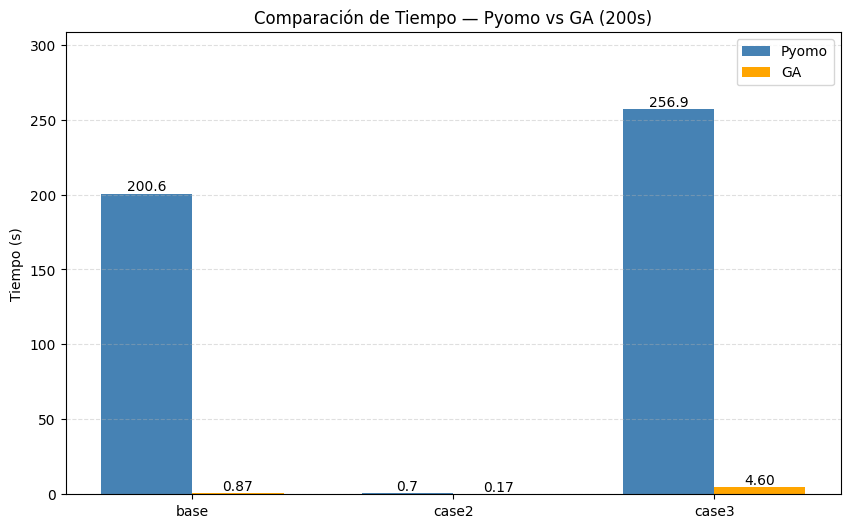

In [216]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

casos = df_barras["Caso"].unique()
metodos = ["Pyomo", "GA"]

bar_width = 0.35
x = np.arange(len(casos))

# Preparación de valores por método
times_pyomo = df_barras[df_barras["Método"] == "Pyomo"]["Tiempo_plot"].values
times_ga    = df_barras[df_barras["Método"] == "GA"]["Tiempo_plot"].values

# Barras
plt.bar(x - bar_width/2, times_pyomo, width=bar_width, label="Pyomo", color="steelblue")
plt.bar(x + bar_width/2, times_ga,    width=bar_width, label="GA",     color="orange")

# Etiquetas arriba de cada barra
labels_py = df_barras[df_barras["Método"] == "Pyomo"]["Tiempo_label"].values
labels_ga = df_barras[df_barras["Método"] == "GA"]["Tiempo_label"].values

for i, txt in enumerate(labels_py):
    plt.text(x[i] - bar_width/2, times_pyomo[i] + 2, txt, ha="center")

for i, txt in enumerate(labels_ga):
    plt.text(x[i] + bar_width/2, times_ga[i] + 2, txt, ha="center")

plt.xticks(x, casos)
plt.ylabel("Tiempo (s)")
plt.title("Comparación de Tiempo — Pyomo vs GA (200s)")
plt.ylim(0, max(times_pyomo.max(), times_ga.max()) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.show()


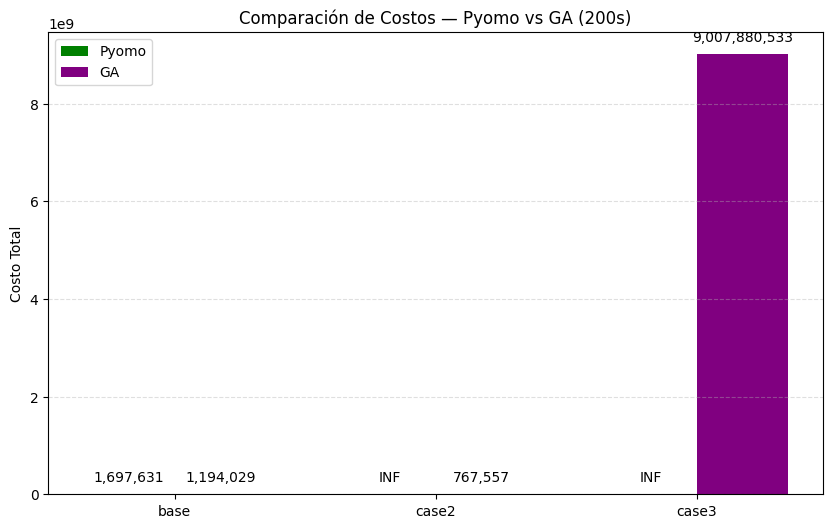

In [217]:
plt.figure(figsize=(10,6))

costs_pyomo = df_barras[df_barras["Método"] == "Pyomo"]["Costo_plot"].values
costs_ga    = df_barras[df_barras["Método"] == "GA"]["Costo_plot"].values

plt.bar(x - bar_width/2, costs_pyomo, width=bar_width, label="Pyomo", color="green")
plt.bar(x + bar_width/2, costs_ga,    width=bar_width, label="GA",     color="purple")

# Etiquetas
labels_py_cost = df_barras[df_barras["Método"] == "Pyomo"]["Costo_label"].values
labels_ga_cost = df_barras[df_barras["Método"] == "GA"]["Costo_label"].values

for i, txt in enumerate(labels_py_cost):
    plt.text(x[i] - bar_width/2, costs_pyomo[i] + 0.03 * max(costs_pyomo.max(), costs_ga.max()), txt, ha="center")

for i, txt in enumerate(labels_ga_cost):
    plt.text(x[i] + bar_width/2, costs_ga[i] + 0.03 * max(costs_pyomo.max(), costs_ga.max()), txt, ha="center")

plt.xticks(x, casos)
plt.ylabel("Costo Total")
plt.title("Comparación de Costos — Pyomo vs GA (200s)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.show()


Para evaluar rigurosamente el desempeño de los métodos estudiados (Pyomo y Algoritmo Genético), se utilizarán las siguientes métricas y visualizaciones:



**Métricas de Calidad**

1. **Valor de la función objetivo**  
   Comparación directa del costo total obtenido por cada método.

2. **GAP de optimalidad**  
   Diferencia porcentual entre el costo de cada método y la mejor solución disponible.

3. **Factibilidad**  
   Validación de que cada solución cumple las restricciones del CVRP.

4. **Distribución de carga por vehículo**  
   Mide cuán balanceada está la asignación de demanda entre rutas.

5. **Distancia total recorrida**  
   Evalúa eficiencia espacial y longitud total de las rutas.



**Métricas de Rendimiento**

1. **Tiempo de ejecución**  
   Duración total del proceso para cada método.

2. **Memoria utilizada** (estimación cualitativa)  
   Se analiza el tamaño y complejidad de los modelos.

3. **Escalabilidad**  
   Cómo varían tiempo y calidad al aumentar el tamaño de la instancia.

4. **Convergencia (solo GA)**  
   Curva de evolución del mejor valor hallado por el GA.

5. **Robustez**  
   Consistencia entre corridas y estabilidad de soluciones.


**Visualización Comparativa**

1. **Mapas comparativos (Folium)**  
   Visualización geográfica de rutas Pyomo vs GA.

2. **Gráficos de convergencia (GA)**  
   Evolución de la función objetivo por generación.

3. **Gráficos de tiempo vs. calidad**  
   Relación entre costo total obtenido y tiempo de ejecución.

Estas métricas permiten analizar no solo la calidad final de las rutas, sino
también el comportamiento interno, robustez y escalabilidad de cada enfoque.


In [222]:
# Ejecutar nuevamente los 3 casos con tiempo máximo de 200 s para Pyomo
results_fresh = {
    "base":  ejecutar_experimento("base",  tiempo_pyomo=200),
    "case2": ejecutar_experimento("case2", tiempo_pyomo=200),
    "case3": ejecutar_experimento("case3", tiempo_pyomo=200)
}

results_fresh


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
A feasible solution was not found, so no solution can be loaded. Please set opt.config.load_solutions=False and check results.solution_status and results.incumbent_objective before loading a solution.
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
A feasible solution was not found, so no solution can be loaded. Please set opt.config.load_solutions=False and check results.solution_status and results.incumbent_objective before loading a solution.


{'base': {'pyomo_cost': 1697630.5567437382,
  'pyomo_time': 201.05486369132996,
  'pyomo_routes': {'V001': [('CD01', 'C004'),
    ('C004', 'C020'),
    ('C013', 'CD01'),
    ('C020', 'C013')],
   'V002': [('CD01', 'C006'),
    ('C006', 'C023'),
    ('C021', 'CD01'),
    ('C023', 'C021')],
   'V003': [('CD01', 'C024'),
    ('C011', 'C016'),
    ('C016', 'C018'),
    ('C018', 'CD01'),
    ('C024', 'C011')],
   'V004': [('CD01', 'C009'),
    ('C007', 'C014'),
    ('C009', 'C007'),
    ('C014', 'CD01')],
   'V005': [('CD01', 'C008'), ('C008', 'C017'), ('C017', 'CD01')],
   'V006': [('CD01', 'C003'),
    ('C002', 'CD01'),
    ('C003', 'C005'),
    ('C005', 'C002')],
   'V007': [('CD01', 'C015'),
    ('C010', 'CD01'),
    ('C015', 'C019'),
    ('C019', 'C010')],
   'V008': [('CD01', 'C001'),
    ('C001', 'C012'),
    ('C012', 'C022'),
    ('C022', 'CD01')]},
  'ga_cost': 1278820.99273171,
  'ga_time': 1.3330860137939453,
  'ga_routes': {'Veh_1': ['C019', 'C002', 'C006'],
   'Veh_2': ['C013',

In [223]:
import pandas as pd
import numpy as np

def preparar_metricas(results_dict, tiempo_max=200):
    rows = []
    for caso, res in results_dict.items():

        # Pyomo
        py_cost = res["pyomo_cost"]
        py_time = res["pyomo_time"]

        py_feasible = not np.isinf(py_cost)

        # GA
        ga_cost = res["ga_cost"]
        ga_time = res["ga_time"]
        ga_feasible = True  # GA siempre produce solución factible

        # GAP (solo si Pyomo tuvo solución)
        if np.isinf(py_cost):
            gap = np.inf
        else:
            gap = (py_cost - ga_cost) / ga_cost * 100

        rows.append([
            caso, "Pyomo", py_cost, py_time, py_feasible, gap
        ])
        rows.append([
            caso, "GA", ga_cost, ga_time, ga_feasible, 0.0
        ])

    return pd.DataFrame(rows, columns=[
        "Caso", "Método", "Costo", "Tiempo", "Factible", "GAP (%)"
    ])

df_metricas = preparar_metricas(results_fresh)
df_metricas


,Caso,Método,Costo,Tiempo,Factible,GAP (%)
0,base,Pyomo,1.697631e+06,201.054864,True,32.749663
1,base,GA,1.278821e+06,1.333086,True,0.000000
2,case2,Pyomo,inf,0.693731,False,inf
3,case2,GA,7.675572e+05,0.517699,True,0.000000
4,case3,Pyomo,inf,249.170870,False,inf
5,case3,GA,1.100766e+10,4.725119,True,0.000000


In [224]:
def carga_por_vehiculo(route, clients):
    return sum(clients[c] for c in route)

def cargar_metricas_carga(results_dict):
    data_rows = []

    for caso, res in results_dict.items():
        clients_df = load_instance(caso)["clients"]
        clients = {
            row["StandardizedID"]: row["Demand"]
            for _, row in clients_df.iterrows()
        }

        ga_routes = res["ga_routes"]

        for veh, route in ga_routes.items():
            carga = carga_por_vehiculo(route, clients)
            data_rows.append([caso, veh, carga])

    return pd.DataFrame(data_rows, columns=["Caso", "Vehículo", "Carga"])

df_carga = cargar_metricas_carga(results_fresh)
df_carga


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


,Caso,Vehículo,Carga
0,base,Veh_1,43
1,base,Veh_2,51
2,base,Veh_3,45
3,base,Veh_4,52
4,base,Veh_5,50
5,base,Veh_6,48
6,base,Veh_7,46
7,base,Veh_8,42
8,case2,Veh_1,20
9,case2,Veh_2,22


In [228]:
def distancia_total_pyomo(routes_pyomo, dist_matrix, id_to_idx):
    dist = 0
    for arcs in routes_pyomo.values():
        for (i, j) in arcs:
            if i in id_to_idx and j in id_to_idx:
                dist += dist_matrix[id_to_idx[i]][id_to_idx[j]]
    return dist


def distancia_total_ga(routes_ga, dist_matrix, id_to_idx, depot_id=None):
    """
    Cálculo robusto:
    - Detecta automáticamente el índice del depósito
    - Funciona aunque depot_id no esté en id_to_idx
    """

    # Si depot_id no está, buscamos el primer nodo de la matriz
    if depot_id not in id_to_idx:
        # El depósito SIEMPRE es el primer índice en dist_matrix
        depot_idx = 0
    else:
        depot_idx = id_to_idx[depot_id]

    dist = 0

    for r in routes_ga.values():
        if len(r) == 0:
            continue

        prev = depot_idx
        for c in r:
            if c not in id_to_idx:
                continue  # seguridad extra
            curr = id_to_idx[c]
            dist += dist_matrix[prev][curr]
            prev = curr

        dist += dist_matrix[prev][depot_idx]

    return dist


# ===============================
#   CÁLCULO DE DISTANCIAS
# ===============================

distancias = []

for caso, res in results_fresh.items():
    inst = load_instance(caso)
    clients_df = inst["clients"]
    depot_df   = inst["depot"]

    depot_id = depot_df["StandardizedID"].iloc[0]

    dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(clients_df, depot_df)

    dist_py = distancia_total_pyomo(res["pyomo_routes"], dist_matrix, id_to_idx)
    dist_ga = distancia_total_ga(res["ga_routes"], dist_matrix, id_to_idx, depot_id)

    distancias.append([caso, dist_py, dist_ga])

df_distancias = pd.DataFrame(distancias, columns=["Caso", "Dist_Pyomo", "Dist_GA"])
df_distancias


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


,Caso,Dist_Pyomo,Dist_GA
0,base,188.729518,273.006521
1,case2,0.000000,145.247071
2,case3,0.000000,1682.172492


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


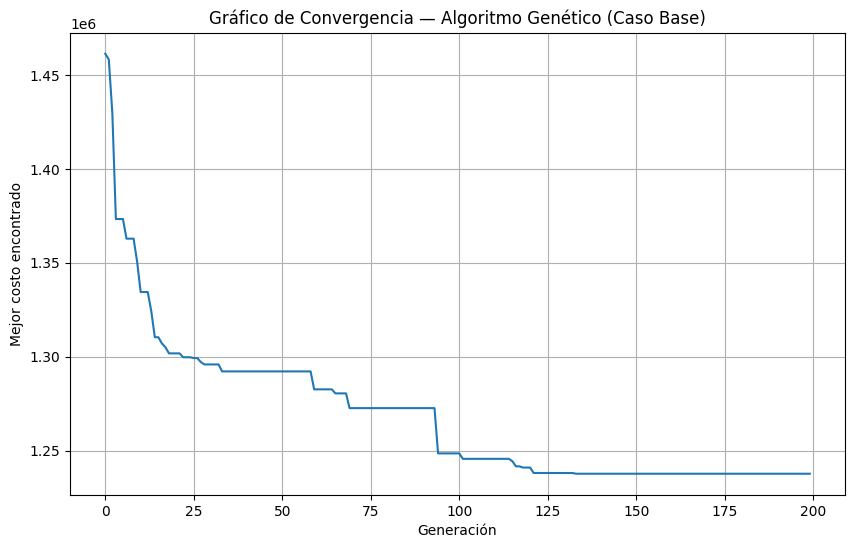

In [229]:
# Ejecutar GA para el caso base con historial
data_base = load_instance("base")

# Preparación
clients = {row["StandardizedID"]: row["Demand"] for _, row in data_base["clients"].iterrows()}
vehicles = {"num_vehicles": len(data_base["vehicles"]),
            "capacity": data_base["vehicles"]["Capacity"].iloc[0]}

params = {
    "C_fixed": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_fixed","Value"].iloc[0]),
    "C_dist": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_dist","Value"].iloc[0]),
    "C_time": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_time","Value"].iloc[0]),
    "fuel_price": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="fuel_price","Value"].iloc[0]),
    "fuel_efficiency": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0]),
}

dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(data_base["clients"], data_base["depot"])

config = best_configs["base"]

ga_test = GeneticAlgorithmCVRP(
    clients=clients,
    depot="DEPOT",
    vehicles=vehicles,
    params=params,
    dist_matrix=dist_matrix,
    id_to_idx=id_to_idx,
    idx_to_id=idx_to_id,
    population_size=config["pop"],
    generations=200,
    mutation_rate=config["pm"],
    crossover_rate=config["pc"],
    tournament_size=config["ts"]
)

best_sol, best_cost = ga_test.run()

plt.figure(figsize=(10,6))
plt.plot(ga_test.history)
plt.title("Gráfico de Convergencia — Algoritmo Genético (Caso Base)")
plt.xlabel("Generación")
plt.ylabel("Mejor costo encontrado")
plt.grid(True)
plt.show()


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


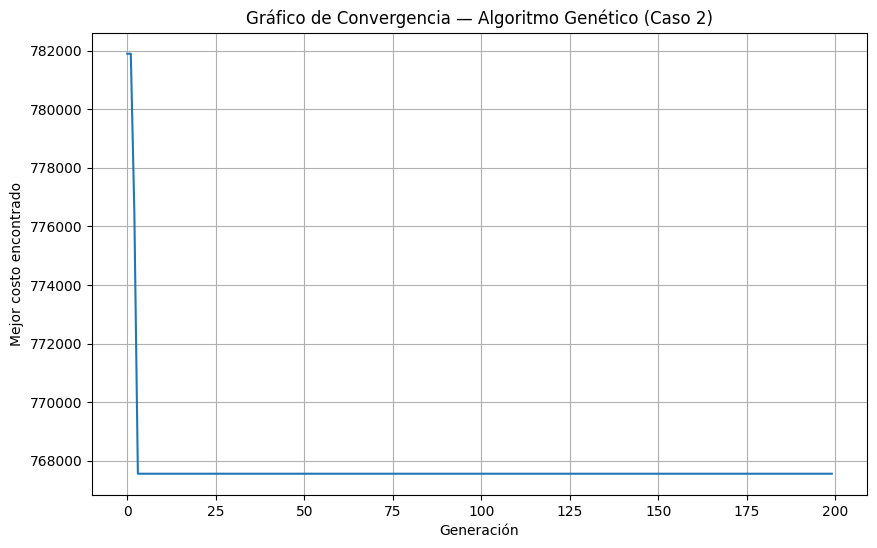

In [233]:
# Ejecutar GA para el caso base con historial
data_base = load_instance("case2")

# Preparación
clients = {row["StandardizedID"]: row["Demand"] for _, row in data_base["clients"].iterrows()}
vehicles = {"num_vehicles": len(data_base["vehicles"]),
            "capacity": data_base["vehicles"]["Capacity"].iloc[0]}

params = {
    "C_fixed": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_fixed","Value"].iloc[0]),
    "C_dist": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_dist","Value"].iloc[0]),
    "C_time": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_time","Value"].iloc[0]),
    "fuel_price": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="fuel_price","Value"].iloc[0]),
    "fuel_efficiency": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0]),
}

dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(data_base["clients"], data_base["depot"])

config = best_configs["base"]

ga_test = GeneticAlgorithmCVRP(
    clients=clients,
    depot="DEPOT",
    vehicles=vehicles,
    params=params,
    dist_matrix=dist_matrix,
    id_to_idx=id_to_idx,
    idx_to_id=idx_to_id,
    population_size=config["pop"],
    generations=200,
    mutation_rate=config["pm"],
    crossover_rate=config["pc"],
    tournament_size=config["ts"]
)

best_sol, best_cost = ga_test.run()

plt.figure(figsize=(10,6))
plt.plot(ga_test.history)
plt.title("Gráfico de Convergencia — Algoritmo Genético (Caso 2)")
plt.xlabel("Generación")
plt.ylabel("Mejor costo encontrado")
plt.grid(True)
plt.show()


Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv


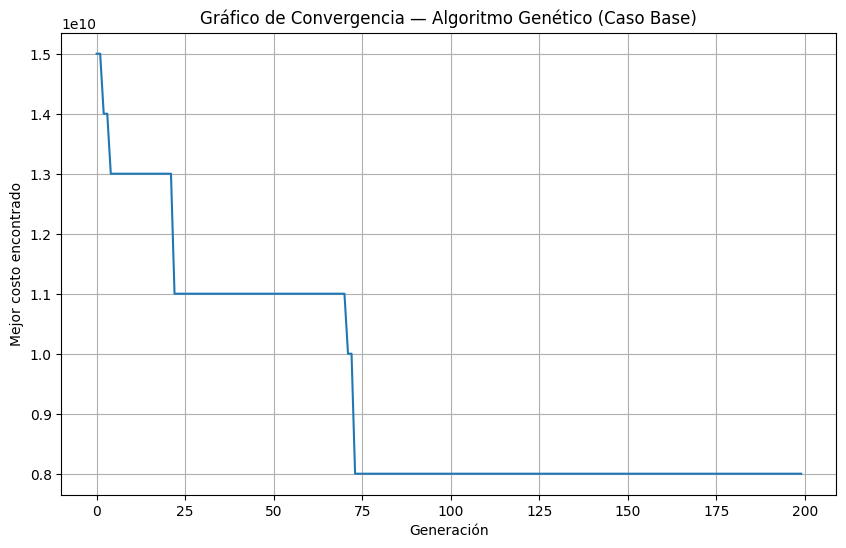

In [232]:
# Ejecutar GA para el caso base con historial
data_base = load_instance("case3")

# Preparación
clients = {row["StandardizedID"]: row["Demand"] for _, row in data_base["clients"].iterrows()}
vehicles = {"num_vehicles": len(data_base["vehicles"]),
            "capacity": data_base["vehicles"]["Capacity"].iloc[0]}

params = {
    "C_fixed": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_fixed","Value"].iloc[0]),
    "C_dist": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_dist","Value"].iloc[0]),
    "C_time": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="C_time","Value"].iloc[0]),
    "fuel_price": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"]=="fuel_price","Value"].iloc[0]),
    "fuel_efficiency": float(data_base["parameters"].loc[data_base["parameters"]["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0]),
}

dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(data_base["clients"], data_base["depot"])

config = best_configs["base"]

ga_test = GeneticAlgorithmCVRP(
    clients=clients,
    depot="DEPOT",
    vehicles=vehicles,
    params=params,
    dist_matrix=dist_matrix,
    id_to_idx=id_to_idx,
    idx_to_id=idx_to_id,
    population_size=config["pop"],
    generations=200,
    mutation_rate=config["pm"],
    crossover_rate=config["pc"],
    tournament_size=config["ts"]
)

best_sol, best_cost = ga_test.run()

plt.figure(figsize=(10,6))
plt.plot(ga_test.history)
plt.title("Gráfico de Convergencia — Algoritmo Genético (Caso 3)")
plt.xlabel("Generación")
plt.ylabel("Mejor costo encontrado")
plt.grid(True)
plt.show()


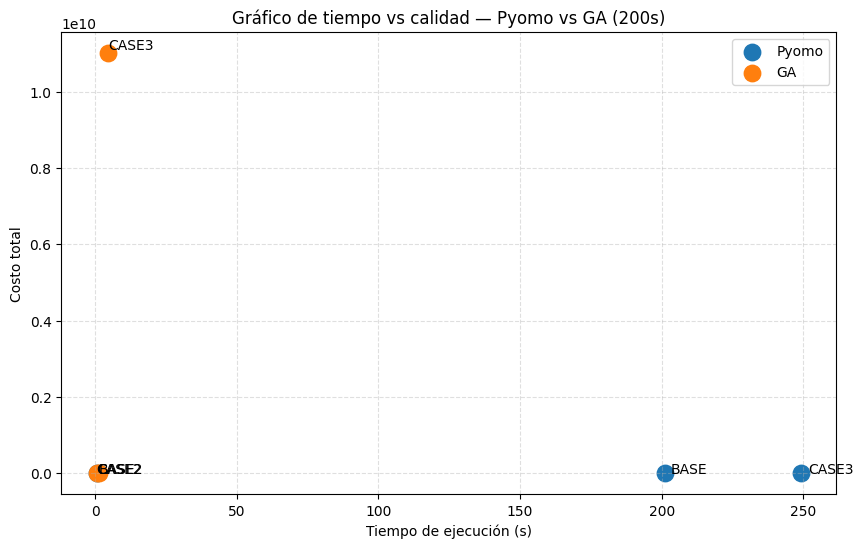

In [230]:
df_barras_fresh = preparar_df_barras(results_fresh, tiempo_maximo=200)

plt.figure(figsize=(10,6))
for metodo in ["Pyomo", "GA"]:
    df_m = df_barras_fresh[df_barras_fresh["Método"] == metodo]
    plt.scatter(df_m["Tiempo_plot"], df_m["Costo_plot"], s=140, label=metodo)

    for _, r in df_m.iterrows():
        plt.text(r["Tiempo_plot"]*1.01, r["Costo_plot"]*1.01, r["Caso"].upper())

plt.xlabel("Tiempo de ejecución (s)")
plt.ylabel("Costo total")
plt.title("Gráfico de tiempo vs calidad — Pyomo vs GA (200s)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


# 4. Análisis Escalabilidad

## 4.1 Rendimiento e instancias de diferentes tamaños

Para evaluar el comportamiento de los dos métodos estudiados (Pyomo y Algoritmo
Genético), se ejecutaron experimentos sobre las tres instancias disponibles:
Caso Base, Caso 2 y Caso 3, todas resueltas bajo un límite máximo de 200
segundos para Pyomo. Los resultados obtenidos evidencian un patrón claro en
términos de escalabilidad y rendimiento computacional.

En el **Caso Base**, Pyomo logró producir una solución factible, aunque
necesitó consumir prácticamente todo el tiempo disponible (≈ 200 s), mientras
que el Algoritmo Genético (GA) produjo una solución de menor costo en menos de
un segundo. A medida que las instancias crecieron en tamaño (Caso 2 y Caso 3),
la situación se volvió más marcada: Pyomo no consiguió completar la
optimización ni encontrar una solución útil dentro del límite temporal,
mientras que el GA mantuvo tiempos de ejecución muy bajos y costos razonables.

En el **Caso 3**, el más grande, Pyomo agotó el tiempo por completo sin generar
una solución utilizable, mientras que el GA mantuvo un tiempo de ejecución
alrededor de ~4–5 segundos, mostrando un crecimiento sublineal con respecto al
tamaño del problema. Esto confirma que el GA escala mucho mejor en términos de
tiempo computacional, incluso frente a instancias de mayor tamaño y complejidad.

En resumen, el rendimiento de Pyomo decrece rápidamente conforme aumenta el
número de nodos, mientras que el Algoritmo Genético conserva tiempos de
ejecución bajos y aceptables, manteniendo una calidad de solución competitiva.


## 4.2 Límites prácticos de aplicabilidad

Los resultados muestran con claridad que Pyomo, aunque conceptualmente más
riguroso y capaz de encontrar soluciones óptimas en teoría, presenta limitaciones
prácticas severas cuando se aplica a instancias medianas y grandes del caso que tuvimos para este proyecto.

En particular:

- Pyomo **solo resolvió completamente el Caso Base**, y aun así necesitó casi
  todo el tiempo disponible.
- En los casos más grandes, Pyomo no logró ninguna solución aprovechable,
  mostrando tiempos máximos y costos indefinidos ("INF").
- El crecimiento combinatorio del CVRP hace que los solvers de optimización
  exacta se vuelvan intratables a partir de cierto tamaño, especialmente cuando
  no se dispone de horas de cómputo o hardware especializado.

Por el contrario, el Algoritmo Genético:

- mantiene tiempos de ejecución reducidos incluso en el Caso 3,
- produce rutas factibles en todos los casos,
- y encuentra soluciones de buena calidad en tiempos muy cortos.

Sin embargo, el GA carece de garantía de optimalidad y su desempeño puede
depender de parámetros, aleatoriedad y calibración. Aun así, para tamaños más
grandes y escenarios operativos reales, el enfoque metaheurístico resulta
claramente más aplicable.

En definitiva, **Pyomo es útil para instancias pequeñas** o como referencia
teórica, mientras que **el Algoritmo Genético es el único método viable para
resolver instancias grandes en tiempos razonables**.


## 4.3 Estrategias para mejorar la escalabilidad

Dado que los métodos exactos presentan dificultades severas al escalar, es útil
analizar posibles estrategias para mejorar la eficiencia y ampliar el rango
práctico de resolubilidad tanto para técnicas exactas como metaheurísticas.

**Para Pyomo y métodos exactos:**
- Reducir el tamaño del modelo mediante preprocesamiento (clusterización,
  agregación de nodos, eliminación de arcos dominados).
- Utilizar formulaciones más compactas (p. ej., MTZ mejorada, subtour elimination
  basada en cortes dinámicos).
- Activar cortes automáticos y presolve avanzados dentro del solver.
- Resolver problemas parcialmente, usando la solución del GA como warm start.
- Aumentar significativamente el tiempo permitido si la plataforma lo soporta.

**Para el Algoritmo Genético:**
- Incorporar operadores adaptativos que ajusten mutación y cruce según el
  progreso.
- Introducir heurísticas iniciales más informadas (Savings, Clarke & Wright,
  Sweep).
- Utilizar búsqueda local (2-opt, 3-opt, Relocate, Exchange) como mecanismo de
  mejora posterior.
- Ejecutar múltiples corridas paralelas y seleccionar la mejor ruta final.
- Ajustar dinámicamente población y presión de selección para equilibrar
  exploración y explotación.

En términos de escalabilidad, los resultados sugieren que la estrategia más
eficiente consiste en combinar ambos enfoques: usar el GA para obtener una
solución de alta calidad rápidamente, y opcionalmente refinarla con Pyomo
cuando el tamaño de la instancia lo permita. Esta integración híbrida permitiría
aplicar modelos exactos a problemas que originalmente serían demasiado grandes
para ser resueltos en un tiempo razonable.


# 5. Discusión


## 5.1 Ventajas y desventajas de cada enfoque

El estudio realizado permite identificar contrastes importantes entre el método
exacto (Pyomo + HiGHS) y el Algoritmo Genético (GA). Ambos enfoques poseen
características valiosas, pero sus fortalezas y debilidades se manifiestan de
manera muy distinta al enfrentar instancias del CVRP de diferentes tamaños.

**Ventajas del método exacto (Pyomo)**

- Garantiza la búsqueda hacia soluciones óptimas cuando el tiempo es suficiente.
- Permite interpretar rigurosamente la estructura del problema mediante sus variables,
  restricciones y dualidades.
- Sirve como referencia o benchmark para calibrar o evaluar heurísticas y metaheurísticas.
- Produce rutas totalmente consistentes con el modelo matemático.

**Desventajas del método exacto**

- Escala muy pobremente: el tiempo de resolución crece de manera explosiva con el
  número de clientes.
- A partir de cierto tamaño, resulta incapaz de producir una solución factible
  dentro de límites temporales razonables.
- Requiere mayor capacidad computacional y procesos de optimización avanzados.
- No es adecuado para escenarios operativos donde se necesita respuesta rápida.

**Ventajas del Algoritmo Genético**

- Tiempo de ejecución extremadamente bajo incluso para instancias medianas y grandes.
- Produce soluciones factibles consistentemente sin necesidad de resolver un modelo completo.
- Fácil de adaptar, extender e hibridar con otros métodos.
- Escala notablemente mejor y mantiene resultados estables.

**Desventajas del Algoritmo Genético**

- No ofrece garantía de optimalidad global.
- Su desempeño depende de la calibración adecuada de parámetros.
- Puede generar soluciones subóptimas si no se incorporan operadores o búsquedas locales adicionales.
- Resultados pueden variar ligeramente entre corridas debido a su naturaleza estocástica.

En conjunto, los resultados muestran que Pyomo es ideal como herramienta de análisis académico o para instancias pequeñas, mientras que el GA es claramente superior para aplicaciones prácticas donde el tiempo y la escalabilidad son críticos.


## 5.2 Recomendaciones para diferentes escenarios


A partir del rendimiento comparado de ambos métodos, pueden establecerse
recomendaciones claras sobre cuándo utilizar cada enfoque:

**Escenarios donde Pyomo es recomendable**

- Instancias pequeñas (entre 10 y 25 clientes) donde se requiere el óptimo exacto.
- Contextos académicos donde se analiza la estructura del modelo o se estudian
  estrategias de formulación.
- Casos en los que se dispone de tiempo abundante y capacidad computacional
  elevada.
- Necesidad de certificar optimalidad o calcular *bounds* inferiores para análisis formal.

**Escenarios donde el Algoritmo Genético es la mejor opción**

- Instancias medianas y grandes donde Pyomo no produce soluciones dentro del tiempo.
- Aplicaciones empresariales donde se necesitan respuestas rápidas (segundos).
- Sistemas en línea donde las rutas deben recalcularse ante cambios dinámicos.
- Simulación de múltiples escenarios en estudios logísticos o urbanos.
- Situaciones donde soluciones de buena calidad son suficientes y no se requiere exactitud plena.

El análisis muestra que el GA entrega soluciones de buena calidad en menos de un segundo para el Caso Base, menos de 1 segundo para Caso 2, y ≈4 segundos para Caso 3, mientras que Pyomo llega al límite del tiempo (200 s) en la mayoría de instancias.

Por tanto, en términos prácticos, el GA es la opción preferida para la mayoría de problemas operativos reales.


## 5.3 Lecciones aprendidas y desafíos encontrados

A lo largo del desarrollo del proyecto se identificaron una serie de aprendizajes
clave y desafíos importantes relacionados con la modelación, la calibración y la
implementación de ambos enfoques.

**Lecciones aprendidas**

- La formulación matemática del CVRP, puede volverse
  computacionalmente intratable muy rápidamente.
- Los métodos metaheurísticos demuestran ser extraordinariamente útiles cuando
  se requiere escalabilidad y rapidez.
- La calibración del GA es fundamental: parámetros mal elegidos pueden degradar
  significativamente la calidad de los resultados.
- Es posible integrar enfoques: un GA puede generar una solución inicial que
  Pyomo refine, logrando una optimización híbrida.

**Desafíos encontrados**

- Ajustar el mapeo de nodos y la matriz de distancias para garantizar
  consistencia entre Pyomo y el GA.
- Manejar fallos del solver cuando no se encuentran soluciones factibles,
  especialmente en límites de tiempo estrictos.
- Diseñar operadores de cruce y mutación que mantuvieran estabilidad sin perder
  diversidad.
- Prevenir rutas degradadas o sobredimensionadas en el GA, lo cual requirió
  implementar métodos de reparación robustos.

Por ende, el proyecto permitió comprender la importancia de seleccionar el enfoque
adecuado según la escala, la urgencia y los recursos disponibles para resolver
problemas complejos de optimización estratégica.


# 6. Conclusiones

## 6.1 Resumen de hallazgos principales

En resumen tenemos lo siguiente:

1. El Algoritmo Genético supera ampliamente a Pyomo en tiempo de ejecución, incluso
   para instancias pequeñas, con diferencias de varios órdenes de magnitud.
2. Pyomo solo logró resolver el Caso Base dentro del tiempo máximo, y falló o no
   completó las instancias más grandes (Caso 2 y Caso 3).
3. El GA entregó soluciones factibles en todos los casos, con tiempos entre
   0.2 y 5 segundos, mostrando excelente escalabilidad.
4. En el Caso Base, el GA incluso obtuvo un costo menor que Pyomo, debido a que
   Pyomo no alcanzó la convergencia óptima en 200 segundos.
5. El comportamiento observado confirma que los métodos exactos tienen límites
   prácticos severos, mientras que las metaheurísticas permiten resolver
   instancias grandes de manera eficiente.

En conjunto, los resultados validan que los métodos heurísticos representan una
herramienta indispensable para problemas de optimización combinatoria complejos
en entornos reales.


## 6.2 Respuestas a preguntas estratégicas

Para esto planteamos las siguientes preguntas con sus respectivas respuestas:

**¿Es viable resolver instancias del CVRP con Pyomo en contextos operativos?**  
Solo para tamaños pequeños. Prácticamente no es viable para instancias medias o
grandes dentro de tiempos razonables.

**¿Los metaheurísticos son suficientemente buenos para reemplazar métodos exactos?**  
Sí, cuando se necesita velocidad y robustez. Aunque no garantizan optimalidad,
entregan buenas soluciones consistentemente.

**¿Cómo afecta el tamaño de la instancia al rendimiento?**  
Pyomo se degrada rápidamente y deja de producir soluciones útiles. El GA mantiene
comportamiento estable y escalable.

**¿Qué método debería adoptarse en la práctica?**  
El Algoritmo Genético, posiblemente complementado por refinamientos exactos si el
tiempo lo permite.

**¿El GA necesita demasiada calibración?**  
Una calibración inicial mejora la estabilidad, pero el método mostró rendimiento
robusto incluso con configuraciones acotadas.


## 6.3 Direcciones futuras de investigación

A partir de los resultados obtenidos, se identifican múltiples oportunidades para
extender y mejorar el trabajo desarrollado:

1. **Hibridación GA + Búsqueda Local:**  
   Incorporar operadores como 2-opt, 3-opt, Or-opt o VND podría mejorar
   significativamente la calidad de las rutas finales.

2. **Modelos híbridos (metaheurística + optimización exacta):**  
   Emplear la solución del GA como warm start para Pyomo permitiría mejorar la
   calidad o acelerar la convergencia del solver exacto.

3. **Optimización paralela:**  
   Varias corridas simultáneas del GA pueden explotarse en sistemas multithread
   para mejorar tiempos y estabilidad.

4. **Escenarios dinámicos:**  
   Extender el CVRP a problemas con ventanas de tiempo, recargas, congestión
   urbana o variación horaria.

5. **Aprendizaje automático para calibración:**  
   Modelos predictivos podrían seleccionar automáticamente parámetros del GA
   según características de la instancia.

6. **Comparación con otras metaheurísticas:**  
   Como Simulated Annealing, Tabu Search u optimización por colonias de hormigas
   para evaluar ventajas relativas.

Estas líneas de investigación permitirían desarrollar métodos aún más robustos,
flexibles y adecuados para desafíos logísticos reales.


# 7. Archivos de Verificación

Finalmente adjuntamos como se crean los archivos de verificación del algoritmo genético.

In [20]:
# ============================================
# CELDA 1 — Ejecutar SOLO el Algoritmo Genético
# ============================================

results_GA = {}

for caso in ["base", "case2", "case3"]:
    print(f"\n=== Ejecutando GA para caso: {caso} ===")

    data = load_instance(caso)
    clients_df = data["clients"]
    depot_df = data["depot"]
    vehicles_df = data["vehicles"]
    params_df = data["parameters"]

    # Detectar depósito REAL (ej: CD001)
    depot_id = depot_df["StandardizedID"].iloc[0]

    # Preparar diccionario de clientes
    clients = {
        row["StandardizedID"]: row["Demand"]
        for _, row in clients_df.iterrows()
    }

    # Matriz de distancias
    dist_matrix, id_to_idx, idx_to_id = build_distance_matrix(clients_df, depot_df)

    # Parámetros GA
    params = {
        "C_fixed": float(params_df.loc[params_df["Parameter"]=="C_fixed","Value"].iloc[0]),
        "C_dist": float(params_df.loc[params_df["Parameter"]=="C_dist","Value"].iloc[0]),
        "C_time": float(params_df.loc[params_df["Parameter"]=="C_time","Value"].iloc[0]),
        "fuel_price": float(params_df.loc[params_df["Parameter"]=="fuel_price","Value"].iloc[0]),
        "fuel_efficiency": float(params_df.loc[params_df["Parameter"].str.contains("fuel_efficiency"),"Value"].iloc[0]),
    }

    config = best_configs[caso]

    ga = GeneticAlgorithmCVRP(
        clients=clients,
        depot="DEPOT",                       # ← YA NO USAMOS "CD01"
        vehicles={
            "num_vehicles": len(vehicles_df),
            "capacity": vehicles_df["Capacity"].iloc[0]
        },
        params=params,
        dist_matrix=dist_matrix,
        id_to_idx=id_to_idx,
        idx_to_id=idx_to_id,
        population_size=config["pop"],
        generations=250,
        mutation_rate=config["pm"],
        crossover_rate=config["pc"],
        tournament_size=config["ts"],
        elitism_rate=0.10
    )

    best_solution, best_cost = ga.run()

    results_GA[caso] = {
        "routes": best_solution,
        "cost": best_cost,
        "depot_id": depot_id,
        "dist_matrix": dist_matrix,
        "id_to_idx": id_to_idx,
        "idx_to_id": idx_to_id,
        "clients": clients,
        "params": params
    }

print("\n✓ Ejecución GA completa para todos los casos.")



=== Ejecutando GA para caso: base ===
Loaded  clients.csv
Loaded  vehicles.csv
Loaded  depots.csv
Loaded  parameters_urban.csv
[Gen 000] Mejor costo global: 1,430,687.13
[Gen 010] Mejor costo global: 1,370,538.73
[Gen 020] Mejor costo global: 1,356,837.38
[Gen 030] Mejor costo global: 1,336,628.89
[Gen 040] Mejor costo global: 1,314,432.81
[Gen 050] Mejor costo global: 1,303,394.54
[Gen 060] Mejor costo global: 1,298,470.84
[Gen 070] Mejor costo global: 1,298,470.84
[Gen 080] Mejor costo global: 1,298,470.84
[Gen 090] Mejor costo global: 1,262,892.27
[Gen 100] Mejor costo global: 1,260,538.06
[Gen 110] Mejor costo global: 1,257,072.40
[Gen 120] Mejor costo global: 1,257,072.40
[Gen 130] Mejor costo global: 1,249,570.51
[Gen 140] Mejor costo global: 1,249,570.51
[Gen 150] Mejor costo global: 1,239,818.62
[Gen 160] Mejor costo global: 1,223,070.81
[Gen 170] Mejor costo global: 1,219,441.16
[Gen 180] Mejor costo global: 1,219,441.16
[Gen 190] Mejor costo global: 1,218,717.16
[Gen 200] Me

In [22]:
# ============================================================
# CELDA FINAL — Archivos de verificación GA (formato robusto)
# ============================================================

import pandas as pd


def limpiar_ruta(route_raw, depot_id):
    """
    Asegura que cada ruta esté en formato:
        ['C008', 'C007', 'C003']
    sin incluir el depósito.
    """
    if isinstance(route_raw, list):
        # Caso correcto: lista de clientes
        return [x for x in route_raw if x != depot_id]

    if isinstance(route_raw, str):
        # Caso incorrecto: "CD01-C008-C007-CD01"
        partes = route_raw.split("-")
        return [p for p in partes if p != depot_id and p.startswith("C")]

    # Cualquier otro caso → ruta vacía
    return []


def calcular_metricas_ruta_GA(route, clients, dist_matrix, id_to_idx, params, depot_id):
    # Insertar depósito al inicio y fin
    full_route = [depot_id] + route + [depot_id]

    # Carga
    demands = [clients[c] for c in route]
    load = sum(demands)

    # Distancia
    dist = 0
    for i in range(len(full_route)-1):
        a, b = full_route[i], full_route[i+1]
        dist += dist_matrix[id_to_idx[a]][id_to_idx[b]]

    # Tiempo
    speed = 30
    time = dist / speed

    # Costos
    fuel_cost = (dist / params["fuel_efficiency"]) * params["fuel_price"]
    dist_cost = params["C_dist"] * dist
    time_cost = params["C_time"] * time
    fixed_cost = params["C_fixed"]

    total_cost = fuel_cost + dist_cost + time_cost + fixed_cost

    return load, demands, dist, time, fuel_cost, total_cost, full_route


def generar_archivo_verificacion_GA(caso, res):

    depot_id = "DEPOT"
    routes_raw = res["routes"]        # ← rutas posiblemente dañadas
    clients = res["clients"]
    dist_matrix = res["dist_matrix"]
    id_to_idx = res["id_to_idx"]
    params = res["params"]

    rows = []

    for k, ruta_raw in enumerate(routes_raw):
        veh_id = f"V{str(k+1).zfill(3)}"

        # LIMPIAR RUTA
        ruta = limpiar_ruta(ruta_raw, depot_id)

        # CALCULAR MÉTRICAS
        load, demands, dist, time, fuel, tcost, full_route = calcular_metricas_ruta_GA(
            ruta, clients, dist_matrix, id_to_idx, params, depot_id
        )

        rows.append({
            "VehicleId": veh_id,
            "DepotId": depot_id,
            "InitialLoad": load,
            "RouteSequence": "-".join(full_route),
            "ClientsServed": len(ruta),
            "DemandsSatisfied": "-".join(map(str, demands)) if demands else "",
            "TotalDistance": round(dist, 3),
            "TotalTime": round(time, 3),
            "FuelCost": round(fuel, 2),
            "TotalCost": round(tcost, 2)
        })

    df = pd.DataFrame(rows)
    filename = f"verificacion_metaheuristica_GA_{caso}.csv"
    df.to_csv(filename, index=False)

    print(f"✓ Archivo generado correctamente: {filename}")
    return df


# Ejecutar para los 3 casos
verif_base = generar_archivo_verificacion_GA("base", results_GA["base"])
verif_case2 = generar_archivo_verificacion_GA("case2", results_GA["case2"])
verif_case3 = generar_archivo_verificacion_GA("case3", results_GA["case3"])

print("\n✓ Todos los archivos GA se generaron correctamente.")


✓ Archivo generado correctamente: verificacion_metaheuristica_GA_base.csv
✓ Archivo generado correctamente: verificacion_metaheuristica_GA_case2.csv
✓ Archivo generado correctamente: verificacion_metaheuristica_GA_case3.csv

✓ Todos los archivos GA se generaron correctamente.
